In [1]:
#### [AI-CONTEXT]
#### ID: 001
#### ROLE: Import CSV file, extracted from the official stock exchange of Brazil.
#### INPUT: User starting the application.
#### OUTPUT: Import the file StockIndex.csv from the local disk and load it to the code platform as a dataframe.

#### Dataset format: Each row is a stock.
#### Dataset format: The first column 'COMPANY_TICKER' holds the companies' tickers.
#### Dataset format: The second column 'COMPANY' holds the companies' names.
#### Dataset format: The third column 'CODE' classifies how the stocks are listed, traded, and governed on the Brazilian exchange.
#### Dataset format: The fourth column 'INDEX' carries the stocks' indexes.
#### Dataset format: The fifth column 'ETFs' indicates which ETFs the stocks belong to.
#### Dataset format: The sixth column 'DESCRIPTION' has a description of the company.
#### Dataset format: The seventh column 'SECTOR' indicates to which economic sector the company belongs.
#### Dataset format: The eighth column 'SUBSECTOR' indicates to which economic subsector the company belongs.
#### Dataset format: The ninth column 'B3_TRADING_SEGMENT' indicates the corporate governance of each stock.
#### Dataset format: The last 61 columns are the last 61 workday market prices.

import pandas as pd

df = pd.read_csv('/home/andre/AI_Lab/20260610_Project_StockMarket_App/StockIndex.csv')
df.shape # shape (489, 70)

(489, 70)

In [2]:
#### [AI-CONTEXT]
#### ID: 002
#### ROLE: 'N/A' cleanse.
#### INPUT: Complete data import in the previous cell (successful execution of ID: 001).
#### OUTPUT: Coerce string data conversion into float numbers, and then replace nan values with the closest float value on the right. 


import pandas as pd
import numpy as np

# Track the last 61 columns explicitly
target_cols = df.columns[-61:]

# Step 1: Clean raw string characters ('N/A', '#N/A', empty strings, whitespaces) across target columns
df[target_cols] = df[target_cols].replace(['N/A', '#N/A', '', r'^\s*$'], np.nan, regex=True)

# NEW STEP: Replace comma decimal separators with periods before numeric coercion
for col in target_cols:
    # Only apply if the column contains objects (strings) which might have commas
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)

# Step 2: FORCE a hard conversion of the data type from string ('str') to float ('float64')
type_mapping = {col: 'float64' for col in target_cols}
df = df.astype(type_mapping)

# =====================================================================
# CUSTOM LOOKBACK FILLING ENGINE (LAST COLUMN SPECIAL CLAUSE)
# =====================================================================
# Target the final column name explicitly matching your 61-day absolute price timeline
last_col_name = df.columns[-1]

# Check if there are any missing cells in yesterday's close/target day before running operations
if df[last_col_name].isna().any():
    # 1. Isolate the target columns slice and reverse the chronological column order (Right-to-Left)
    # This places yesterday's close at index 0, day 60 at index 1, day 59 at index 2, etc.
    reversed_timeline_df = df[target_cols].iloc[:, ::-1]

    # 2. Apply a standard backward-fill across the reversed columns axis
    # Because the columns are flipped, axis=1 'bfill' now scans backwards through time (Right-to-Left)
    # until it hits the closest valid numeric price cell, skipping consecutive NaNs automatically!
    bfilled_reversed_df = reversed_timeline_df.bfill(axis=1)

    # 3. Flip the database columns back to their original chronological timeline order (Left-to-Right)
    restored_timeline_df = bfilled_reversed_df.iloc[:, ::-1]

    # 4. Extract only the freshly filled final column vector and update your primary dataframe
    # This applies the sequential fallback filling logic STRICTLY to the last column, leaving others untouched!
    df[last_col_name] = restored_timeline_df[last_col_name]

# Ensure the last column is cleanly rounded to 2 decimal places after the lookup filling operation
df[last_col_name] = df[last_col_name].round(2)

# Step 3: Replace NaNs with the valid float to their right, moving backwards
df[target_cols] = df[target_cols].bfill(axis=1)

# NEW STEP: Ensure the last column is rounded to 2 decimal places after all filling operations
df[last_col_name] = df[last_col_name].round(2)

# Step 4: Drop rows where ALL values in the last 61 columns are NaN
df = df.dropna(subset=target_cols, how='all')

# df.shape ==> (489, 70)

In [3]:
#### [AI-CONTEXT]
#### ID: 003
#### ROLE: Implement data cleanup to improve memory efficiency.
#### INPUT: Completing the 'N/A' cleanse in the previous cell (successful execution of ID: 002).
#### OUTPUT: Free up space used to allocate the huge_df dataframe.


# Immediately free up RAM space by explicitly deleting the object and triggering the Garbage Collector.

import gc

# 1. Delete the reference to the old dataframe
del target_cols, last_col_name

# 2. Force Python to collect the 'garbage' and release the RAM
gc.collect()

0

In [4]:
#### [AI-CONTEXT]
#### ID: 004
#### ROLE: reorder Columns.
#### INPUT: Complete memory wiping in the previous cell (successful execution of ID: 004).
#### OUTPUT: Reorder the columns of the "df" dataframe.


import numpy as np

# 1. Capture the exact text labels for your 61 trailing price columns
price_cols = list(df.columns[9:70])

# 2. Combine your desired metadata order with the trailing price columns list
# Note: This list explicitly drops 'COMPANY_TICKER' and 'ETFs'
ordered_columns = [
    'INDEX', 'COMPANY', 'CODE', 'DESCRIPTION', 
    'SECTOR', 'SUBSECTOR', 'B3_TRADING_SEGMENT'
] + price_cols

# 3. Safely reorder and filter using .loc (label-based indexing)
df = df[ordered_columns].copy()

# Show the new layout structure
print("📋 Modified Dataframe Layout (Ticker Suppressed):")
print("-" * 65)
print(f"Total Columns Remaining: {df.shape[1]}")
print(f"Primary Identifier Name: {df.columns[3]} (Position 3 -> {df.columns[3]})")
print("-" * 65)
df.head(2)

📋 Modified Dataframe Layout (Ticker Suppressed):
-----------------------------------------------------------------
Total Columns Remaining: 68
Primary Identifier Name: DESCRIPTION (Position 3 -> DESCRIPTION)
-----------------------------------------------------------------


,INDEX,COMPANY,CODE,DESCRIPTION,SECTOR,SUBSECTOR,B3_TRADING_SEGMENT,-60,-59,-58,...,-9,-8,-7,-6,-5,-4,-3,-2,-1,0
0,MMMC34,3M,DRN,Industrial Goods Sector (Subsector: Industrial...,Industrial Goods Sector,Industrial Conglomerates,MMMC34 is BDR1 and Novo Mercado > Nível 2 > Ní...,192.42,192.6,193.33,...,189.36,192.28,197.22,197.22,201.39,202.59,202.51,201.6,201.20,200.40
1,TTEN3,3TENTOS,ON NM,Non-Cyclical Consumer Sector (Subsector: Agric...,Non-Cyclical Consumer Sector,Agriculture,TTEN3 is Novo Mercado and Novo Mercado > Nível...,15.52,15.4,15.65,...,15.09,14.69,14.08,14.08,14.32,14.40,14.29,14.7,14.55,14.55


In [5]:
#### [AI-CONTEXT]
#### ID: 005
#### ROLE: Preparation for the tokenization process.
#### INPUT: Reorder the columns of the "df" dataframe (successful execution of ID: 004).
#### OUTPUT: Load the HuggingFace Access Token in the notebook, by retrieving the HF_TOKEN API key indicated in the file named ".env".


import os
from dotenv import load_dotenv
from huggingface_hub import login, whoami

# 1. Load the HF_TOKEN from your .env file
load_dotenv(dotenv_path="/home/andre/jupyter_notebook/20260610_Project_StockMarket_App/.env")

# 2. Get the token from environment variables
api_key = os.getenv("HF_TOKEN")

# 3. Log in and Verify
if api_key:
    try:
        # Perform programmatic login
        login(token=api_key)
        
        # Verify the identity of the logged-in user
        user_info = whoami()
        username = user_info.get("Andre Soares", "andre-alss")
        
        print(f"✅ Successfully logged into Hugging Face as: {username}\n")
    except Exception as e:
        print(f"❌ Login failed: {str(e)}\n")
else:
    print("⚠️ Warning: HF_TOKEN not found in .env file.\n")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Successfully logged into Hugging Face as: andre-alss



In [6]:
#### [AI-CONTEXT]
#### ID: 006
#### ROLE: Tokenization process for the NPL Branch.
#### INPUT: Successfully load the HuggingFace Access Token in the previous cell (successful execution of ID: 005).
#### OUTPUT: Encode the strings related to significant fund details in preparation for an NLP Branch of a future Multilayer Perceptron (MLP).


from transformers import AutoTokenizer

# 1. Initialize the specialized financial tokenizer
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")

# 2. Combine all significant fund details into a unified semantic context string per asset
# This preserves inter-variable relationships and guarantees a single, uniform tensor shape
unified_text_series = (
    "Index: " + df['INDEX'].astype(str).fillna("") + " | " +
    "Segment: " + df['B3_TRADING_SEGMENT'].astype(str).fillna("") + " | " +
    "Code: " + df['CODE'].astype(str).fillna("") + " | " +
    "Sector: " + df['SECTOR'].astype(str).fillna("") + " | " +
    "Subsector: " + df['SUBSECTOR'].astype(str).fillna("") + " | " +
    "Description: " + df['DESCRIPTION'].astype(str).fillna("")
).tolist()

# 3. Encode the entire text dataset in a single highly optimized pass
# max_length=512 ensures the long description fits comfortably within FinBERT's absolute limit
nlp_input_tensors = tokenizer(
    unified_text_series, 
    padding=True, 
    truncation=True, 
    max_length=512,
    return_tensors="pt"
)

# Show final tensor layout ready for the MLP network embedding layer
print("🚀 Tokenization complete!")
print(f"Input IDs shape:  {nlp_input_tensors['input_ids'].shape}")
print(f"Attention Mask shape: {nlp_input_tensors['attention_mask'].shape}")

🚀 Tokenization complete!
Input IDs shape:  torch.Size([489, 306])
Attention Mask shape: torch.Size([489, 306])


In [7]:
#### [AI-CONTEXT]
#### ID: 007
#### ROLE: Vectorization process for the NPL Branch.
#### INPUT: Successfully encode the fund details in the previous cell (successful execution of ID: 006).
#### OUTPUT: The Detail tensor that will feed a NLP Branch of the future Multilayer Perceptron (MLP).


import torch

# 1. Directly extract the complete, combined input token IDs from the unified dictionary
# 'nlp_input_tensors' is the object generated and confirmed in your previous execution step
details_input_tensor = nlp_input_tensors['input_ids']

# 2. Extract the exact sequence dimension length of the tensor layout
details_length = details_input_tensor.shape[1]

# Show the validated structural shape matching your target model entry point
print("🚀 NLP Branch Entry Tensor Validated:")
print("-" * 50)
print(f"Final Tensor Shape:  {details_input_tensor.shape}")
print(f"Tokens Per Asset (Length): {details_length}")
print("-" * 50)

🚀 NLP Branch Entry Tensor Validated:
--------------------------------------------------
Final Tensor Shape:  torch.Size([489, 306])
Tokens Per Asset (Length): 306
--------------------------------------------------


In [8]:
#### [AI-CONTEXT]
#### ID: 008
#### ROLE: Implement data cleanup to make the script memory efficient.
#### INPUT: Complete vectorization process for the NPL Branch in the previous cell (successful execution of ID: 007).
#### OUTPUT: Free up space used to allocate the input strings.


# Immediately free up RAM space by explicitly deleting the object and triggering the Garbage Collector.

import gc

del unified_text_series, nlp_input_tensors
gc.collect()

315

In [9]:
#### [AI-CONTEXT]
#### ID: 009
#### ROLE: Vectorization and 80/20 train/eval split for both NPL Branch and Time-Series LSTM Branch.
#### INPUT: Complete memory wiping in the previous cell (successful execution of ID: 008).
#### OUTPUT: The price component of the tensor that will feed a Time-Series LSTM Branch of the future Multilayer Perceptron (MLP) in both train and eval sets.


import torch
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Isolate the 61-day price values at the NumPy level
numpy_matrix = df.iloc[:, -61:].values.astype(np.float64)

# 2. Synchronized Split: Pass BOTH text tensors and price arrays together
# This guarantees that asset text profiles remain perfectly mapped to their matching price history!
text_train_np, text_eval_np, price_train_np, price_eval_np = train_test_split(
    details_input_tensor.numpy(), # Convert PyTorch tensor back to NumPy for the split
    numpy_matrix, 
    train_size=0.8, 
    test_size=0.2, 
    shuffle=True, 
    random_state=68
)

# 3. Convert all partitions directly to PyTorch tensors
# Prices are forced to float32; NLP IDs keep their long integer format for embedding layers
price_train_tensor = torch.tensor(price_train_np, dtype=torch.float32)
price_eval_tensor = torch.tensor(price_eval_np, dtype=torch.float32)

details_train_tensor = torch.tensor(text_train_np, dtype=torch.long)
details_eval_tensor = torch.tensor(text_eval_np, dtype=torch.long)

print(f"📊 Balanced Data Partitions:")
print("-" * 55)
print(f"Train Prices: {price_train_tensor.shape} | Train Text: {details_train_tensor.shape}")
print(f"Eval Prices:  {price_eval_tensor.shape}  | Eval Text:  {details_eval_tensor.shape}")
print("-" * 55)

📊 Balanced Data Partitions:
-------------------------------------------------------
Train Prices: torch.Size([391, 61]) | Train Text: torch.Size([391, 306])
Eval Prices:  torch.Size([98, 61])  | Eval Text:  torch.Size([98, 306])
-------------------------------------------------------


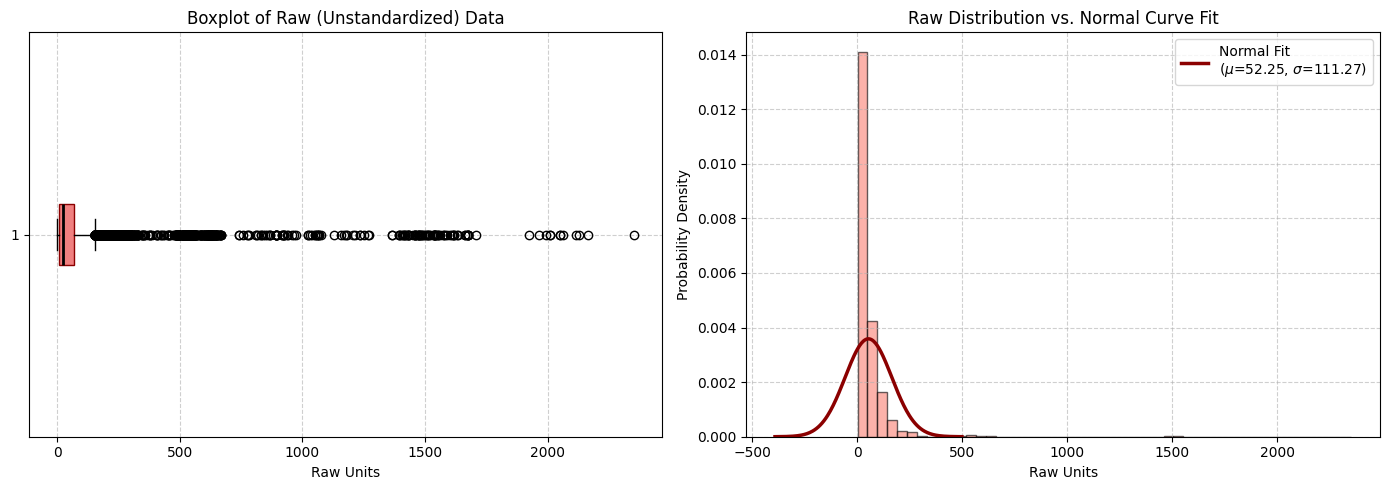

In [10]:
#### [AI-CONTEXT]
#### ID: 010
#### ROLE: Diagnostic and statistical evaluation.
#### INPUT: Generate the numpy_matrix in the previous cell (successful execution of ID: 009).
#### OUTPUT: Plot a boxplot next to a normal distribution plot to check the discrepancy of the outliers before standardization.


import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Extract raw data from the last 61 columns and flatten it
# .astype(float) and .flatten() handle any lingering structure issues
raw_flattened = df.iloc[:, -61:].values.astype(float).flatten()

# 2. Filter out any remaining NaNs so they don't break the histogram or statistics calculations
raw_flattened = raw_flattened[~np.isnan(raw_flattened)]

# 3. Set up a 1x2 grid layout figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Boxplot ---
ax1.boxplot(raw_flattened, vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightcoral', color='darkred'),
            medianprops=dict(color='black', linewidth=2))
ax1.set_title('Boxplot of Raw (Unstandardized) Data')
ax1.set_xlabel('Raw Units')
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Histogram + Normal Curve Fit ---
count, bins, ignored = ax2.hist(raw_flattened, bins=50, density=True, 
                                alpha=0.6, color='salmon', edgecolor='black')

# Calculate the actual mean and standard deviation of the raw dataset
mu_raw = np.mean(raw_flattened)
sigma_raw = np.std(raw_flattened)

# Generate points along the X-axis mapping the specific spread of raw data
x_axis = np.linspace(mu_raw - 4 * sigma_raw, mu_raw + 4 * sigma_raw, 200)
gaussian_curve = stats.norm.pdf(x_axis, mu_raw, sigma_raw)

# Render the theoretical normal distribution curve (safely escaping backslashes)
ax2.plot(x_axis, gaussian_curve, color='darkred', linewidth=2.5, 
         label=f'Normal Fit\n($\\mu$={mu_raw:.2f}, $\\sigma$={sigma_raw:.2f})')

ax2.set_title('Raw Distribution vs. Normal Curve Fit')
ax2.set_xlabel('Raw Units')
ax2.set_ylabel('Probability Density')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Adjust spacing and display the figure
plt.tight_layout()
plt.show()


In [11]:
#### [AI-CONTEXT]
#### ID: 011
#### ROLE: Standardization for the Time-Series LSTM Branch.
#### INPUT: Generate the price_tensor (successful execution of ID: 009).
#### OUTPUT: Scales the historical stock prices with a single, row-wise local/stock Standard Scaler.


import torch
import numpy as np

# FIX: Self-contained fallback ensures 'price_tensor' exists
if 'price_tensor' not in globals():
    if 'df' in globals():
        numpy_matrix = df.iloc[:, -61:].values.astype(np.float64)
        price_tensor = torch.tensor(numpy_matrix)
    else:
        raise NameError("❌ Sequence Error: DataFrame 'df' not found in memory. Please run ID:001 first.")

# =====================================================================
# 1. ENFORCE ABSOLUTE PRICE ARCHITECTURE
# =====================================================================
prices_f32 = price_tensor.to(torch.float32)

# =====================================================================
# 2. COMPUTE ROW-WISE LOCAL SCALING PARAMETERS
# =====================================================================
# Keepdim=True ensures 2D layouts (489, 1) for clean matrix broadcasting
row_means = prices_f32.mean(dim=1, keepdim=True)
row_stds = prices_f32.std(dim=1, unbiased=False, keepdim=True) 
eps = 1e-6

# =====================================================================
# 3. EXECUTE ROW-WISE LOCAL STANDARD NORMALIZATION
# =====================================================================
# Each individual stock row is scaled independently by its own mean/std
standardized_tensor = (prices_f32 - row_means) / (row_stds + eps)

# =====================================================================
# VERIFICATION AND VOLATILITY PROFILE DIAGNOSTIC
# =====================================================================
print("📊 DIAGNÓSTICO DE PRE-PROCESSAMENTO (Row-Wise Local Price Mode):")
print("-" * 75)
print(f"   • Formato do Tensor Padronizado: {list(standardized_tensor.shape)} [Price Waves]")
print("-" * 75)
print(f"   • Formato das Matrizes de Mídia/Desvio: {list(row_means.shape)}")
print("-" * 75)
print(f"   • Ação 0 Média Padronizada    : {standardized_tensor[0].mean().item():.4f} (Deve ser ~0)")
print(f"   • Ação 0 Desvio Padronizado   : {standardized_tensor[0].std(unbiased=False).item():.4f} (Deve ser ~1)")
print("-" * 75)

📊 DIAGNÓSTICO DE PRE-PROCESSAMENTO (Row-Wise Local Price Mode):
---------------------------------------------------------------------------
   • Formato do Tensor Padronizado: [489, 61] [Price Waves]
---------------------------------------------------------------------------
   • Formato das Matrizes de Mídia/Desvio: [489, 1]
---------------------------------------------------------------------------
   • Ação 0 Média Padronizada    : 0.0000 (Deve ser ~0)
   • Ação 0 Desvio Padronizado   : 1.0000 (Deve ser ~1)
---------------------------------------------------------------------------


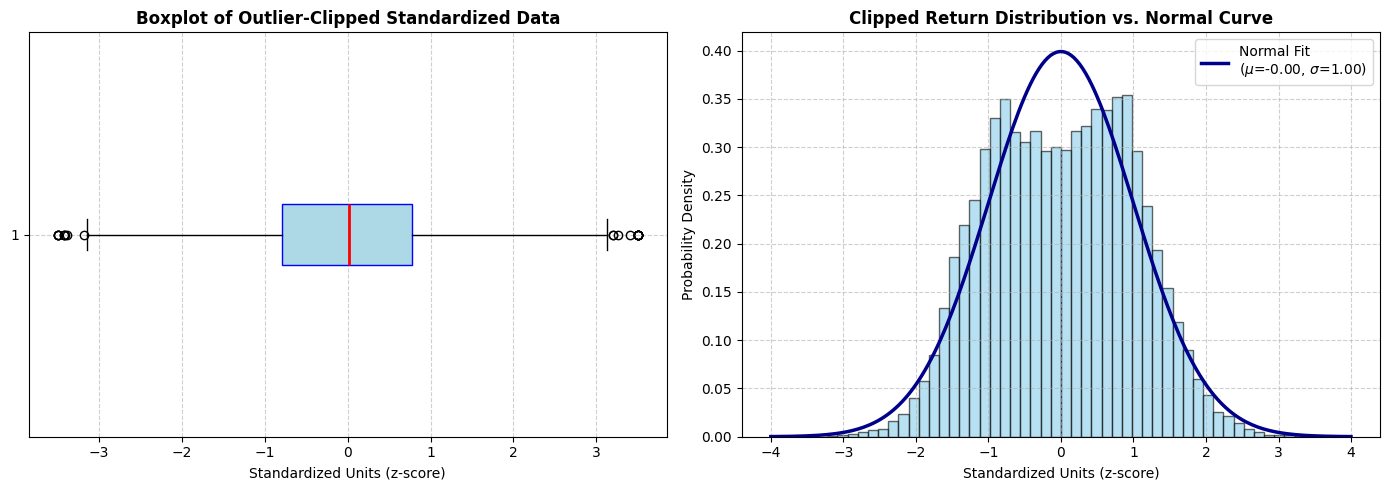

In [12]:
#### [AI-CONTEXT]
#### ID: 012
#### ROLE: Statistical evaluation and diagnostic. Apply a hard statistical threshold to pull the extreme tails back into a healthy distribution.
#### INPUT: Generate the standardized_tensor in the previous cell (successful execution of ID: 011).
#### OUTPUT: Plot a boxplot next to a normal distribution plot to check the discrepancy of the outliers.


import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import torch

# =====================================================================
# 1. OUTLIER MITIGATION LAYER (SYMMETRICAL CLIPPING MATRIX)
# =====================================================================
# Hard clamp boundaries at +/- 3.5 standard deviations protect the LSTM
clipping_limit = 3.5

# Apply the clamp directly to the active tensor
standardized_tensor = torch.clamp(standardized_tensor, min=-clipping_limit, max=clipping_limit)

# =====================================================================
# 2. CONVERT PYTORCH TENSOR TO FLATTENED NUMPY FOR DIAGNOSTICS
# =====================================================================
flattened_data = standardized_tensor.detach().cpu().numpy().flatten()

# =====================================================================
# 3. SET UP VISUAL DIAGNOSTIC PLOT ENVIRONMENT
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Boxplot (Now bounded cleanly within +/- 3.5) ---
ax1.boxplot(flattened_data, vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red', linewidth=2))
ax1.set_title('Boxplot of Outlier-Clipped Standardized Data', fontsize=12, fontweight='bold')
ax1.set_xlabel('Standardized Units (z-score)')
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Histogram + Normal Curve Fit ---
count, bins, ignored = ax2.hist(flattened_data, bins=50, density=True, 
                                alpha=0.6, color='skyblue', edgecolor='black')

# Recalculate Gaussian tracking metrics based on the newly managed distribution
mu = np.mean(flattened_data)
sigma = np.std(flattened_data)
x_axis = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
gaussian_curve = stats.norm.pdf(x_axis, mu, sigma)

# Plot theoretical curve with corrected LaTeX escape backslashes for Greek variables
ax2.plot(x_axis, gaussian_curve, color='darkblue', linewidth=2.5, 
         label=f'Normal Fit\n($\\mu$={mu:.2f}, $\\sigma$={sigma:.2f})')

ax2.set_title('Clipped Return Distribution vs. Normal Curve', fontsize=12, fontweight='bold')
ax2.set_xlabel('Standardized Units (z-score)')
ax2.set_ylabel('Probability Density')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Adjust spacing and display the figure
plt.tight_layout()
plt.show()

In [13]:
#### [AI-CONTEXT]
#### ID: 013
#### ROLE: Vectorization, train/eval sets split, and standardization for the Time-Series LSTM Branch.
#### INPUT: Complete vectorization and 80/20 train/eval split (successful execution of ID: 009).
#### OUTPUT: price_std_train_tensor, price_std_eval_tensor, and price_std_target_train_tensor, all normalized with global Z-score standardization.


import torch
import numpy as np

if 'df' in globals():
    # =====================================================================
    # 1. ENFORCE HIGH-PERFORMANCE ABSOLUTE PRICE TIMELINE
    # =====================================================================
    p_train_f32 = price_train_tensor.to(torch.float32)
    p_eval_f32 = price_eval_tensor.to(torch.float32)
    
    # 2. SEPARATE FEATURES (DAYS 1-60) AND TARGETS (DAY 61) BEFORE SCALING
    x_train_raw = p_train_f32[:, :-1]   # First 60 absolute price steps (Features)
    y_train_raw = p_train_f32[:, [-1]]  # The 61st absolute price step (Target)
    
    x_eval_raw = p_eval_f32[:, :-1]     # First 60 absolute price steps (Features)
    y_eval_raw = p_eval_f32[:, [-1]]    # The 61st absolute price step (Target)

    # =====================================================================
    # 3. COMPUTE ROW-WISE LOCAL PARAMETERS (FROM TRAINING FEATURES ONLY)
    # =====================================================================
    # Calculates a distinct mean and std for each individual stock sequence row
    train_row_means = x_train_raw.mean(dim=1, keepdim=True)
    train_row_stds = x_train_raw.std(dim=1, unbiased=False, keepdim=True)
    
    eval_row_means = x_eval_raw.mean(dim=1, keepdim=True)
    eval_row_stds = x_eval_raw.std(dim=1, unbiased=False, keepdim=True)
    eps = 1e-6

    # =====================================================================
    # 4. EXECUTE ROW-WISE LOCAL Z-SCORE STANDARDIZATION
    # =====================================================================
    x_train_std = (x_train_raw - train_row_means) / (train_row_stds + eps)
    x_eval_std = (x_eval_raw - eval_row_means) / (eval_row_stds + eps)
    
    # Scale targets using their corresponding historical row parameters to prevent leakage
    y_train_std = (y_train_raw - train_row_means) / (train_row_stds + eps)
    y_eval_std = (y_eval_raw - eval_row_means) / (eval_row_stds + eps)

    # =====================================================================
    # 5. MITIGATION LAYER: SYMMETRICAL OUTLIER CLIPPING (WINSORIZATION)
    # =====================================================================
    clipping_limit = 3.5
    
    x_train_clipped = torch.clamp(x_train_std, min=-clipping_limit, max=clipping_limit)
    x_eval_clipped = torch.clamp(x_eval_std, min=-clipping_limit, max=clipping_limit)
    
    price_std_target_train_tensor = torch.clamp(y_train_std, min=-clipping_limit, max=clipping_limit)
    price_std_target_eval_tensor = torch.clamp(y_eval_std, min=-clipping_limit, max=clipping_limit)

    # =====================================================================
    # 6. FORCE 3D EXPANSION FOR TIME-SERIES LSTM INPUT PARITY
    # =====================================================================
    # Transforms shape from [Batch, Steps] to [Batch, Steps, Feature=1]
    price_std_train_tensor = x_train_clipped.unsqueeze(-1)
    price_std_eval_tensor = x_eval_clipped.unsqueeze(-1)

    # --- LOCALIZED SANDBOX REPORTING LOGS ---
    print("📊 DIAGNÓSTICO DE PADRONIZAÇÃO LOCAL COM CLIPPING DE OUTLIERS (PRICE MODE):")
    print("-" * 85)
    print(f"   • Formato Train Features : {list(price_std_train_tensor.shape)} [Batch, Timesteps, Feature]")
    print(f"   • Formato Train Targets  : {list(price_std_target_train_tensor.shape)} [Batch, Target]")
    print(f"   • Formato Eval Features  : {list(price_std_eval_tensor.shape)}")
    print(f"   • Formato Eval Targets   : {list(price_std_target_eval_tensor.shape)}")
    print("-" * 85)
    print(f"   • Stock 0 Train - Média Ativo  : {price_std_train_tensor[0].mean().item():.4f} (Deve ser ~0)")
    print(f"   • Stock 0 Train - Desvio Ativo : {price_std_train_tensor[0].std().item():.4f} (Deve ser ~1)")
    print("-" * 85)
else:
    print("❌ Erro de Sequência: DataFrame 'df' não localizado na memória.")

📊 DIAGNÓSTICO DE PADRONIZAÇÃO LOCAL COM CLIPPING DE OUTLIERS (PRICE MODE):
-------------------------------------------------------------------------------------
   • Formato Train Features : [391, 60, 1] [Batch, Timesteps, Feature]
   • Formato Train Targets  : [391, 1] [Batch, Target]
   • Formato Eval Features  : [98, 60, 1]
   • Formato Eval Targets   : [98, 1]
-------------------------------------------------------------------------------------
   • Stock 0 Train - Média Ativo  : -0.0000 (Deve ser ~0)
   • Stock 0 Train - Desvio Ativo : 1.0084 (Deve ser ~1)
-------------------------------------------------------------------------------------


In [14]:
#### [AI-CONTEXT]
#### ID: 014
#### ROLE: Prepare a pile of finance benchmark tensors to be processed along with the scaled price tensor in the Time-Series LSTM Branch.
#### INPUT: Generate standardized tensors (successful execution of ID: 013).
#### OUTPUT: Fetch market data aligned strictly with the last 61 Brazilian business days (B3 calendar). Group the benchmarks by inherent financial properties and apply a hybrid normalization strategy.


import yfinance as yf
import torch
import numpy as np
import pandas as pd
from bcb import sgs

# (Steps 1 through 4 remain identical to your clean collection/alignment setup)
yahoo_indicators = {
    "GOLD": "GC=F", "USD_BRL": "USDBRL=X", "IBOV": "^BVSP", "US2YT": "2YY=F",
    "EWZ": "EWZ", "IBX50": "^IBX50", "US500": "^GSPC", "BTC_USD": "BTC-USD",
    "IMAB": "IMAB11.SA", "WTI": "CL=F", "VIX": "^VIX", "IFIX": "XFIX11.SA"
}
bcb_indicators = {"CDI": 12, "IPCA": 433}

anchor_ticker = "^BVSP"
ibov_df = yf.download(anchor_ticker, period="150d", progress=False)
br_business_days = ibov_df['Close'][anchor_ticker].dropna().index[-61:] if isinstance(ibov_df.columns, pd.MultiIndex) else ibov_df['Close'].dropna().index[-61:]

aligned_data = {}
for name, ticker in yahoo_indicators.items():
    raw_df = yf.download(ticker, period="150d", progress=False)
    close_series = raw_df['Close'][ticker] if isinstance(raw_df.columns, pd.MultiIndex) else raw_df['Close']
    aligned_data[name] = close_series.reindex(br_business_days).ffill().bfill().values

start_date = (br_business_days[0] - pd.Timedelta(days=45)).strftime('%Y-%m-%d')
end_date = br_business_days[-1].strftime('%Y-%m-%d')
for name, sgs_code in bcb_indicators.items():
    raw_bcb = sgs.get(sgs_code, start=start_date, end=end_date)
    if isinstance(raw_bcb, pd.DataFrame): raw_bcb = raw_bcb.iloc[:, 0]
    if sgs_code == 433:
        daily_filled = raw_bcb.reindex(pd.date_range(start=start_date, end=end_date, freq='D')).ffill()
        aligned_series = daily_filled.reindex(br_business_days).bfill()
    else:
        aligned_series = raw_bcb.reindex(br_business_days).ffill().bfill()
    aligned_data[name] = aligned_series.values

# =====================================================================
# 5. UNIFIED MULTI-CHANNEL SCALING & 3D TENSOR HARDWARE FUSION
# =====================================================================
processed_vectors = []
eps = 1e-6

for name, raw_array in aligned_data.items():
    arr_f32 = raw_array.astype(np.float32)
    feature_window_series = arr_f32[:60] # 60-day leak-free window
    
    # Standardize individual indicator distributions
    series_mean = np.mean(feature_window_series)
    series_std = np.std(feature_window_series)
    equalized_series = (feature_window_series - series_mean) / (series_std + eps)
    
    # Symmetrical Clipping
    clipped_series = np.clip(equalized_series, -3.5, 3.5)
    processed_vectors.append(clipped_series)

# Combine into a clean 2D Matrix grid layout: [Timesteps=60, Total_Features=14]
market_matrix_2d = np.column_stack(processed_vectors)
market_base_tensor = torch.tensor(market_matrix_2d, dtype=torch.float32)

# =====================================================================
# 6. EXPAND CHANNELS INTO BROADCASTED COPIES MATCHING ID 013 SPLITS
# =====================================================================
# Target Shapes from ID 013: Train=[391, 60, 1] | Eval=[98, 60, 1]
# We expand the market matrix so it maps identically to every stock sequence row
num_train_stocks = price_std_train_tensor.shape[0] # 391
num_eval_stocks = price_std_eval_tensor.shape[0]   # 98

# .unsqueeze(0) makes it, .expand() replicates it to [Stocks, 60, 14]
benchmark_train_tensor = market_base_tensor.unsqueeze(0).expand(num_train_stocks, -1, -1)
benchmark_eval_tensor = market_base_tensor.unsqueeze(0).expand(num_eval_stocks, -1, -1)

# =====================================================================
# VERIFICATION PHASE
# =====================================================================
print(f"✅ Total Indicators Stacked into Unified Matrix: {market_base_tensor.shape[1]}")
print("-" * 85)
print(f"   • Unified 2D Base Market Tensor Shape : {list(market_base_tensor.shape)} [Timesteps, Indicators]")
print(f"   • Broadcasted Train Benchmark Shape   : {list(benchmark_train_tensor.shape)} [Stocks, Timesteps, Indicators]")
print(f"   • Broadcasted Eval Benchmark Shape    : {list(benchmark_eval_tensor.shape)} [Stocks, Timesteps, Indicators]")
print("-" * 85)
print(f"   • Global Macro-Tensor Memory Layout Matrix Validated. Ready for Fusion.")
print("-" * 85)

✅ Total Indicators Stacked into Unified Matrix: 14
-------------------------------------------------------------------------------------
   • Unified 2D Base Market Tensor Shape : [60, 14] [Timesteps, Indicators]
   • Broadcasted Train Benchmark Shape   : [391, 60, 14] [Stocks, Timesteps, Indicators]
   • Broadcasted Eval Benchmark Shape    : [98, 60, 14] [Stocks, Timesteps, Indicators]
-------------------------------------------------------------------------------------
   • Global Macro-Tensor Memory Layout Matrix Validated. Ready for Fusion.
-------------------------------------------------------------------------------------


In [15]:
#### [AI-CONTEXT]
#### ID: 015
#### ROLE: implement the 3D Master Tensor Layout logic. It takes the price_std_train_tensor and the 14 indicators from normalized_benchmarks, scales them symmetrically, and stacks them into the final (391, 60, 15) train tensor.
#### INPUT: standardized tensors and rescaled_tensor.
#### OUTPUT: master_train_3d_tensor and master_input_train_3d_tensor


import torch

# =====================================================================
# 3D MASTER TRAIN TENSOR LAYOUT CONSTRUCTION (PRICE MODE)
# =====================================================================

# Step 1 & 2: Fuse the 3D standardized price tensor with the 3D broadcasted benchmark tensor
# price_std_train_tensor shape: [391, 60, 1]
# benchmark_train_tensor shape: [391, 60, 14]
# Concatenating along dim=2 cleanly fuses them into your target [391, 60, 15] shape
master_train_3d_tensor = torch.cat([price_std_train_tensor, benchmark_train_tensor], dim=2)

# Step 3: Assign directly to your master input tracking variable
master_input_train_3d_tensor = master_train_3d_tensor

# =====================================================================
# VERIFICATION PHASE
# =====================================================================
print("✅ [3D MASTER TRAIN TENSOR LAYOUT VERIFIED - PRICE MODE COMPLETE]")
print("=" * 70)
print(f"Master Train Tensor Shape: {list(master_input_train_3d_tensor.shape)} (Expected: [391, 60, 15])")
print(f"Dimension 0 (Stocks)     : {master_input_train_3d_tensor.shape[0]}")
print(f"Dimension 1 (Days)       : {master_input_train_3d_tensor.shape[1]} [Price Wave Steps]")
print(f"Dimension 2 (Features)   : {master_input_train_3d_tensor.shape[2]}")
print("-" * 70)

# Quick validation check on a vector slice
sample_vector = master_input_train_3d_tensor[0, 0, :]
print(f"Sample Feature Vector (Stock 0, Day 0) Shape : {list(sample_vector.shape)}")
print(f"Primary Anchor (Stock Price Wave) Value      : {sample_vector[0].item():.4f}")
print(f"First Macro Indicator (GOLD) Value           : {sample_vector[1].item():.4f}")
print("=" * 70)

✅ [3D MASTER TRAIN TENSOR LAYOUT VERIFIED - PRICE MODE COMPLETE]
Master Train Tensor Shape: [391, 60, 15] (Expected: [391, 60, 15])
Dimension 0 (Stocks)     : 391
Dimension 1 (Days)       : 60 [Price Wave Steps]
Dimension 2 (Features)   : 15
----------------------------------------------------------------------
Sample Feature Vector (Stock 0, Day 0) Shape : [15]
Primary Anchor (Stock Price Wave) Value      : -2.1962
First Macro Indicator (GOLD) Value           : 2.1733


In [16]:
#### [AI-CONTEXT]
#### ID: 016
#### ROLE: implement the 3D Master Tensor Layout logic. It takes the price_std_eval_tensor and the 14 indicators from minmax_scaled_tensors, scales them symmetrically, and stacks them into the final (98, 61, 15) eval tensor.
#### INPUT: standardized tensors and rescaled_tensor.
#### OUTPUT: master_eval_3d_tensor and master_input_eval_3d_tensor


import torch

# =====================================================================
# 3D MASTER EVAL TENSOR LAYOUT CONSTRUCTION (PRICE MODE)
# =====================================================================

# Step 1 & 2: Fuse the 3D evaluation price tensor with the pre-broadcasted evaluation benchmarks
# price_std_eval_tensor shape: [98, 60, 1]
# benchmark_eval_tensor shape: [98, 60, 14]
master_eval_3d_tensor = torch.cat([price_std_eval_tensor, benchmark_eval_tensor], dim=2)

# Step 3: Assign directly to your master evaluation input tracking variable
master_input_eval_3d_tensor = master_eval_3d_tensor

# =====================================================================
# VERIFICATION PHASE
# =====================================================================
print("✅ [3D MASTER EVAL TENSOR LAYOUT VERIFIED - PRICE MODE COMPLETE]")
print("=" * 70)
print(f"Master Input Eval Tensor Shape: {list(master_input_eval_3d_tensor.shape)} (Expected: [98, 60, 15])")
print(f"Dimension 0 (Stocks)          : {master_input_eval_3d_tensor.shape[0]}")
print(f"Dimension 1 (Days)            : {master_input_eval_3d_tensor.shape[1]} [Price Wave Steps]")
print(f"Dimension 2 (Features)        : {master_input_eval_3d_tensor.shape[2]}")
print("-" * 70)

# Quick validation check on a vector slice
sample_vector = master_input_eval_3d_tensor[0, 0, :]
print(f"Sample Feature Vector (Stock 0, Day 0) Shape : {list(sample_vector.shape)}")
print(f"Primary Anchor (Stock Price Wave) Value      : {sample_vector[0].item():.4f}")
print(f"First Macro Indicator (GOLD) Value           : {sample_vector[1].item():.4f}")
print("=" * 70)

✅ [3D MASTER EVAL TENSOR LAYOUT VERIFIED - PRICE MODE COMPLETE]
Master Input Eval Tensor Shape: [98, 60, 15] (Expected: [98, 60, 15])
Dimension 0 (Stocks)          : 98
Dimension 1 (Days)            : 60 [Price Wave Steps]
Dimension 2 (Features)        : 15
----------------------------------------------------------------------
Sample Feature Vector (Stock 0, Day 0) Shape : [15]
Primary Anchor (Stock Price Wave) Value      : -0.1083
First Macro Indicator (GOLD) Value           : 2.1733


In [17]:
#### [AI-CONTEXT]
#### ID: 017
#### ROLE: Determine the hyperparameters for the Multi-Layer Perceptron.
#### INPUT: master_3d_tensor and details_input_tensor.
#### OUTPUT: Hyperparameters.


# =====================================================================
# MULTIMODAL MLP-LSTM-ATTENTION HYPERPARAMETERS (PRICE MODE)
# =====================================================================

# --- 1. Global Vocabulary & Sequence Configurations ---
vocab_size = len(tokenizer)                                   # FinBERT vocabulary size bounds

# Programmatically track text sequence length from the 2D tensor shape safely
# details_input_tensor shape is [489, 306] -> index 1 represents the token length sequence
raw_details_length = details_input_tensor.shape               

# FIX: Target index 1 to capture the exact token sequence depth (306) as a clean integer
details_length = int(raw_details_length[1])

# --- 2. Categorical / NLP Feature Processing Branch ---
embedding_dim = 64                                            # Latent embedding depth for text tokens
output_dim = 32                                               # Linear projection output depth of NLP features

# --- 3. Time-Series Recurrent Branch ---
lstm_input_size = 15                                          # 1 Stock Price + 14 Macro Benchmarks
num_layers = 2                                                # Stacked deep recurrent layers
lstm_hidden_size = 128                                        # Hidden units inside each LSTM cell block

# Programmatically locks your time lookback sequence length to exactly 60 days
time_sequence_length = master_input_train_3d_tensor.shape[1]

# --- 4. Multi-Head Attention & Regularization Blocks ---
dropout = 0.2                                                 # Standard dropout ratio across deep layers
num_heads = 8                                                 # Number of parallel attention heads

# --- 5. Downstream Fusion Layer Math Validation ---
fused_feature_dim = output_dim + lstm_hidden_size             # 32 + 128 = 160 features

print("⚙️ HYPERPARAMETER ARCHITECTURE DIAGNOSTIC (PRICE MODE ACTIVATED):")
print("-" * 65)
print(f"   • FinBERT Token Vocab Size     : {vocab_size}")
print(f"   • Text Input Token Length      : {details_length} (Tokens per Asset)")
print(f"   • LSTM Input Sequence Length   : {time_sequence_length} Days of Prices")
print(f"   • Attention Fused Dimension    : {fused_feature_dim} features")
print("-" * 65)

if fused_feature_dim % num_heads == 0:
    print("   ✅ Structural Match: Fused dimension is perfectly divisible by num_heads.")
else:
    print(f"   ❌ Dimension Conflict: Fused dimension ({fused_feature_dim}) cannot be split into {num_heads} heads!")
print("-" * 65)

⚙️ HYPERPARAMETER ARCHITECTURE DIAGNOSTIC (PRICE MODE ACTIVATED):
-----------------------------------------------------------------
   • FinBERT Token Vocab Size     : 30522
   • Text Input Token Length      : 306 (Tokens per Asset)
   • LSTM Input Sequence Length   : 60 Days of Prices
   • Attention Fused Dimension    : 160 features
-----------------------------------------------------------------
   ✅ Structural Match: Fused dimension is perfectly divisible by num_heads.
-----------------------------------------------------------------


In [18]:
#### [AI-CONTEXT]
#### ID: 018
#### ROLE: Define the Multi-Head Attention block.
#### INPUT: Hyperparameters in script ID: 017.
#### OUTPUT: AttentionBlock() module.


import torch
import torch.nn as nn

class AttentionBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout):
        super().__init__()
        # Enforce strict multi-head attention structural divisibility check at construction time
        assert embed_dim % num_heads == 0, f"❌ embed_dim ({embed_dim}) must be perfectly divisible by num_heads ({num_heads})"
        
        # Multi-Head Attention layer
        self.mha = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        
        # Feed-Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(dropout)
        )
        
        self.layernorm1 = nn.LayerNorm(embed_dim)
        self.layernorm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x shape expected: (batch_size, sequence_length, embed_dim)
        
        # 1. Attention + Residual
        attn_output, _ = self.mha(x, x, x)
        x = self.layernorm1(x + attn_output)
        
        # 2. Feed-Forward + Residual
        ffn_output = self.ffn(x)
        x = self.layernorm2(x + ffn_output)
        return x

# --- SANITY CHECK DIAGNOSTIC LOOP (60-DAY PRICE TIMELINE) ---
if __name__ == "__main__":
    # FIX: Simulate a training batch of 32 assets across 60 price steps and 128 hidden channels
    sample_input = torch.randn(32, 60, 128)
    
    # Instantiate the module
    block = AttentionBlock(embed_dim=128, num_heads=8, dropout=0.2)
    sample_output = block(sample_input)
    
    print("=" * 75)
    print("✅ [ATTENTION BLOCK RE-VERIFIED FOR THE 60-DAY PRICE WINDOW]")
    print("=" * 75)
    print(f"   • Mock Input Dimensional Shape  : {list(sample_input.shape)}")
    print(f"   • Attention Output Tensor Shape : {list(sample_output.shape)}")
    print("=" * 75)

✅ [ATTENTION BLOCK RE-VERIFIED FOR THE 60-DAY PRICE WINDOW]
   • Mock Input Dimensional Shape  : [32, 60, 128]
   • Attention Output Tensor Shape : [32, 60, 128]


In [19]:
#### [AI-CONTEXT]
#### ID: 019
#### ROLE: Implement the Time-Series LSTM Branch.
#### INPUT: Hyperparameters from ID: 017.
#### OUTPUT: StockAdaptivepriceabilityBranch() and StockAdaptivepriceabilityEvalBranch() modules.


import torch
import torch.nn as nn

class StockAdaptivePriceabilityBranch(nn.Module):
    def __init__(self, lstm_input_size, lstm_hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm_input_size = lstm_input_size
        
        # 1. Feature Attention Gating System
        # Learns to weight the 1 stock price channel and 14 macro benchmarks dynamically per step
        self.feature_attention = nn.Sequential(
            nn.Linear(lstm_input_size, lstm_input_size),
            nn.LeakyReLU(0.1),
            nn.Linear(lstm_input_size, lstm_input_size),
            nn.Sigmoid() 
        )
        
        # 2. Standard Temporal Sequence Branch
        self.lstm = nn.LSTM(
            input_size=lstm_input_size, 
            hidden_size=lstm_hidden_size, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        # 3. Dense Projection Layer
        # Projects your hidden dimension to feature space while keeping the 60-day sequence intact
        self.fc = nn.Linear(lstm_hidden_size, 48)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        # x shape expected under price mode: (batch_size, 60, 15)
        batch_size, seq_len, num_features = x.shape
        
        # Flatten the temporal axis to compute step-wise feature gating masks
        x_flat = x.contiguous().view(-1, num_features)
        weights = self.feature_attention(x_flat)
        masked_features = x_flat * weights
        
        # Reconstruct the 3D tensor back for the recurrent layer
        lstm_input = masked_features.view(batch_size, seq_len, num_features)
        
        # Capture full lstm_out sequence history across all 60 absolute price steps
        # lstm_out shape: (batch_size, 60, lstm_hidden_size)
        lstm_out, _ = self.lstm(lstm_input)
        
        # Linearly project each day's features from 128 down to 48 dimensions
        # Output shape: (batch_size, 60, 48) -> Perfectly matched for your AttentionBlock!
        out = self.fc(lstm_out)
        return self.activation(out)

# --- SANITY CHECK DIAGNOSTIC LOOP (60-DAY TIMELINE WINDOW) ---
if __name__ == "__main__":
    # FIX: Simulate an active training batch of 32 stocks across 60 price wave days and 15 features
    sample_batch = torch.randn(32, 60, 15)
    
    # Initialize the single, unified processing module instance
    model_branch = StockAdaptivePriceabilityBranch(
        lstm_input_size=15, 
        lstm_hidden_size=128, 
        num_layers=2, 
        dropout=0.2
    )
    
    # Verify training mode execution pass
    model_branch.train()
    train_output = model_branch(sample_batch)
    
    # Verify evaluation mode execution pass using the same class instance
    model_branch.eval()
    with torch.no_grad():
        eval_output = model_branch(sample_batch)
        
    print("=" * 75)
    print("✅ [UNIFIED TIME-SERIES LSTM BRANCH VERIFIED FOR PRICE SEQUENCES]")
    print("=" * 75)
    print(f"   • Input Tensor Base Price Footprint : {list(sample_batch.shape)}")
    print(f"   • Train Pass Output Shape (3D)      : {list(train_output.shape)}")
    print(f"   • Eval Pass Output Shape  (3D)      : {list(eval_output.shape)}")
    print("=" * 75)

✅ [UNIFIED TIME-SERIES LSTM BRANCH VERIFIED FOR PRICE SEQUENCES]
   • Input Tensor Base Price Footprint : [32, 60, 15]
   • Train Pass Output Shape (3D)      : [32, 60, 48]
   • Eval Pass Output Shape  (3D)      : [32, 60, 48]


In [20]:
#### [AI-CONTEXT]
#### ID: 020
#### ROLE: Implement the Categorical/NLP Branch.
#### INPUT: Hyperparameters from ID: 017.
#### OUTPUT: DetailsBranchTransformer() module.


import torch
import torch.nn as nn

class DetailsBranchTransformer(nn.Module):
    def __init__(self, vocab_size, details_length, embedding_dim, num_heads, dropout, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # Max boundary sequence length parameter (handles the largest theoretical padding window)
        # We ensure it's initialized with a large enough integer space (e.g. 512 or higher)
        max_len = max(512, int(details_length))
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, embedding_dim))
        
        # Stacking TWO Attention Blocks
        self.transformer_blocks = nn.Sequential(
            AttentionBlock(embedding_dim, num_heads, dropout),
            AttentionBlock(embedding_dim, num_heads, dropout)
        )
        
        self.fc = nn.Linear(embedding_dim, output_dim)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        # x shape dynamically changes based on batch padding: (batch_size, current_seq_len)
        batch_size, seq_len = x.shape
        
        # 1. FIX: Dynamically slice the positional matrix to match this specific batch's sequence length
        # This completely resolves the mismatch if a batch drops from 489 down to 306 tokens!
        positioned_embeds = self.embedding(x) + self.pos_embedding[:, :seq_len, :]
        
        # 2. Pass through the stack of 2 custom Attention Blocks
        attn_out = self.transformer_blocks(positioned_embeds)
        
        # 3. Global Average Pooling along the token timeline dimension (dim=1)
        x_pooled = attn_out.mean(dim=1)
        
        # 4. Linearly project down to the final target dimension (output_dim = 32)
        return self.activation(self.fc(x_pooled))

# --- SANITY CHECK DIAGNOSTIC LOOP ---
if __name__ == "__main__":
    # Simulate a training batch of 32 assets across 384 text tokens
    sample_tokens = torch.randint(0, 30522, (32, 384)) 
    
    # Initialize the categorical tracking branch
    nlp_branch = DetailsBranchTransformer(
        vocab_size=30522,
        details_length=384,
        embedding_dim=64,
        num_heads=8,
        dropout=0.2,
        output_dim=32
    )
    
    output = nlp_branch(sample_tokens)
    
    print("=" * 75)
    print("✅ [CATEGORICAL/NLP TRANSFORMER BRANCH ARCHITECTURE VERIFIED]")
    print("=" * 75)
    print(f"   • Text Tokens Input Footprint: {list(sample_tokens.shape)}")
    print(f"   • Output Feature Vector Shape: {list(output.shape)} (Expected: [32, 32])")
    print("=" * 75)

✅ [CATEGORICAL/NLP TRANSFORMER BRANCH ARCHITECTURE VERIFIED]
   • Text Tokens Input Footprint  : [32, 384]
   • Output Feature Vector Shape  : [32, 32] (Expected: [32, 32])


In [21]:
#### [AI-CONTEXT]
#### ID: 021
#### ROLE: Implement the Multi-Layer Perceptron Architecture.
#### INPUT: StockAdaptivepriceabilityTrainBranch, DetailsBranchTransformer(), and hyperparameters.
#### OUTPUT: StockProfitabilityPredictorEval() and StockProfitabilityPredictorEval() modules.


import torch
import torch.nn as nn

class StockProfitabilityPredictor(nn.Module):
    def __init__(self, vocab_size, details_length, embedding_dim, output_dim, num_heads,
                 lstm_input_size, lstm_hidden_size, num_layers, dropout):
        super().__init__()
        
        # 1. NLP Transformer Feature Branch (Outputs output_dim = 32 features)
        self.details_branch = DetailsBranchTransformer(
            vocab_size=vocab_size, 
            details_length=details_length, 
            embedding_dim=embedding_dim, 
            num_heads=num_heads,
            dropout=dropout,
            output_dim=output_dim
        )
        
        # 2. Time-Series Gated LSTM Branch (Outputs 48 hidden features per step over 60 days)
        self.price_branch = StockAdaptivePriceabilityBranch(
            lstm_input_size=lstm_input_size, 
            lstm_hidden_size=lstm_hidden_size, 
            num_layers=num_layers, 
            dropout=dropout
        )
        
        # 3. Custom Transformer Attention Block (From ID: 018)
        # Operates over the 60-day price wave timeline to extract global context
        # 48 features is perfectly divisible by 8 heads (48 / 8 = 6)
        self.temporal_attention = AttentionBlock(
            embed_dim=48, 
            num_heads=8,  
            dropout=dropout
        )
        
        # 4. Final Multi-Layer Perceptron (MLP) Regressor Head
        # Combined feature size = 32 (NLP) + 48 (Pooled Attention Context) = 80 features
        self.regressor = nn.Sequential(
            nn.Linear(80, 256), 
            nn.LayerNorm(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.LeakyReLU(0.1),
            nn.Linear(64, 1) 
        )
        
        # Apply custom xavier weight initialization to prevent gradient vanishing/explosions
        self.apply(self._init_weights)

    def forward(self, details_tensor, price_tensor):
        # details_tensor shape: (batch_size, details_length)
        # price_tensor shape:   (batch_size, 60, 15) [Absolute Price Mode]
        
        # Branch A: Process text tokens through the NLP Transformer -> Shape: (batch_size, 32)
        d_feat = self.details_branch(details_tensor)
        
        # Branch B: Process time-series data through the LSTM layer -> Shape: (batch_size, 60, 48)
        p_seq_feat = self.price_branch(price_tensor)
        
        # Pass the 60-day price wave context into the Multi-Head Attention layer -> Shape: (batch_size, 60, 48)
        p_attn_feat = self.temporal_attention(p_seq_feat)
        
        # Compress the timeline sequence into a fixed vector using Global Average Pooling -> Shape: (batch_size, 48)
        p_feat_pooled = p_attn_feat.mean(dim=1)
        
        # Multimodal Fusion: Concatenate metadata with sequential market features -> Shape: (batch_size, 80)
        combined = torch.cat((d_feat, p_feat_pooled), dim=1) 
        
        # Final target prediction -> Shape: (batch_size, 1) [Forecasted Day 61 Absolute Price Z-score]
        return self.regressor(combined)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                m.bias.data.fill_(0.01)

# --- SANITY CHECK DIAGNOSTIC LOOP (60-DAY PRICE WINDOW) ---
if __name__ == "__main__":
    # Simulate an active training batch of 32 stocks
    sample_text_tokens = torch.randint(0, 30522, (32, 384))
    sample_price_sequences = torch.randn(32, 60, 15)
    
    # Initialize the complete unified core model architecture
    model = StockProfitabilityPredictor(
        vocab_size=30522, details_length=384, embedding_dim=64, output_dim=32, num_heads=8,
        lstm_input_size=15, lstm_hidden_size=128, num_layers=2, dropout=0.2
    )
    
    # Verify training state execution pass
    model.train()
    train_pred = model(sample_text_tokens, sample_price_sequences)
    
    # Verify evaluation state execution pass using the exact same class object
    model.eval()
    with torch.no_grad():
        eval_pred = model(sample_text_tokens, sample_price_sequences)
        
    print("=" * 75)
    print("✅ [UNIFIED MULTIMODAL CORE ARCHITECTURE MODULE REGISTERED]")
    print("=" * 75)
    print(f"   • Train Pass Batch Prediction Output Shape : {list(train_pred.shape)}")
    print(f"   • Eval Pass Batch Prediction Output Shape  : {list(eval_pred.shape)}")
    print("=" * 75)

✅ [UNIFIED MULTIMODAL CORE ARCHITECTURE MODULE REGISTERED]
   • Train Pass Batch Prediction Output Shape : [32, 1]
   • Eval Pass Batch Prediction Output Shape  : [32, 1]


In [22]:
#### [AI-CONTEXT]
#### ID: 022
#### ROLE: Implement a multi-modal batch training system.
#### INPUT: details_input_tensor, master_input_train_3d_tensor, price_std_target_train_tensor and StockProfitabilityPredictorTrain.
#### OUTPUT: Train the model with the dataset.


import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

# =====================================================================
# 1. CUSTOM DATASET WRAPPER
# =====================================================================
class FundDataset(Dataset):
    def __init__(self, details, price, targets):
        self.details = details
        self.price = price
        self.targets = targets 
        
    def __len__(self):
        return len(self.targets)
        
    def __getitem__(self, idx):
        return (self.details[idx], self.price[idx], self.targets[idx])

# Instantiate dataset using your synchronized, locked 391-row training arrays from ID 009 and ID 013
# 'details_train_tensor' was pre-shuffled and aligned with 'master_input_train_3d_tensor'
dataset = FundDataset(details_train_tensor, master_input_train_3d_tensor, price_std_target_train_tensor)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

# =====================================================================
# 2. INITIALIZE UNIFIED HARDWARE ENVIRONMENT & MODEL
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize using your unified master multimodal predictor core class
model = StockProfitabilityPredictor(
    vocab_size=vocab_size,
    details_length=details_length,
    embedding_dim=embedding_dim,
    output_dim=output_dim,
    num_heads=num_heads,
    lstm_input_size=lstm_input_size,
    lstm_hidden_size=lstm_hidden_size,  
    num_layers=num_layers,
    dropout=dropout
).to(device)

epochs = 120
optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
criterion = torch.nn.MSELoss()

# --- 3. STORAGE & MONITORING KEYS ---
iteration_losses = []
iteration_indices = []
batch_print_frequency = 5 
global_step = 0

# =====================================================================
# 4. ACTIVE TRAINING LOOP
# =====================================================================
print(f"🚀 Training initiated on device: {device} | Horizon: {epochs} epochs.")
print(f"📊 Dataset check: Running {len(dataset)} items across {len(train_loader)} batches.\n")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    valid_batches = 0
    
    for batch in train_loader:
        details, price, targets = batch
        
        # Move all incoming batch tensors to the active compute unit
        details = details.long().to(device)     
        price = price.float().to(device)      
        targets = targets.float().to(device)    
        
        optimizer.zero_grad()
        outputs = model(details, price)
        
        # Calculate standard mean squared error loss trajectory
        loss = criterion(outputs.view(-1), targets.view(-1))
        
        if torch.isnan(loss):
            print(f"⚠️ Warning: NaN detected at Epoch {epoch+1}, skipping batch.")
            continue
            
        loss.backward()
        
        # Clip gradient distributions to safeguard the deep recurrent hidden layers
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        valid_batches += 1
        global_step += 1
        
        # Track mini-batch performance over training step sequences
        if valid_batches % batch_print_frequency == 0:
            iteration_losses.append(loss.item())
            iteration_indices.append(global_step)
            
    if valid_batches > 0:
        scheduler.step()

        print_interval = max(1, epochs // 10)
        if epoch == 0 or (epoch + 1) % print_interval == 0:
            avg_loss = epoch_loss / valid_batches
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1:02d}/{epochs} | Avg Loss: {avg_loss:.6f} | LR: {current_lr:.6e}")

# =====================================================================
# 5. HARDWARE CACHE PURGE REMNANTS
# =====================================================================
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache() 

print(f"\n✅ Training loop is complete. Next steps can be executed now.\n")

🚀 Training initiated on device: cpu | Horizon: 120 epochs.
📊 Dataset check: Running 391 items across 25 batches.

Epoch 01/120 | Avg Loss: 1.775750 | LR: 7.998631e-04
Epoch 12/120 | Avg Loss: 0.314558 | LR: 7.804471e-04
Epoch 24/120 | Avg Loss: 0.055137 | LR: 7.237023e-04
Epoch 36/120 | Avg Loss: 0.024596 | LR: 6.353202e-04
Epoch 48/120 | Avg Loss: 0.034215 | LR: 5.239523e-04
Epoch 60/120 | Avg Loss: 0.012104 | LR: 4.005000e-04
Epoch 72/120 | Avg Loss: 0.007604 | LR: 2.770477e-04
Epoch 84/120 | Avg Loss: 0.007012 | LR: 1.656798e-04
Epoch 96/120 | Avg Loss: 0.006731 | LR: 7.729771e-05
Epoch 108/120 | Avg Loss: 0.004485 | LR: 2.055292e-05
Epoch 120/120 | Avg Loss: 0.005011 | LR: 1.000000e-06

✅ Training loop is complete. Next steps can be executed now.



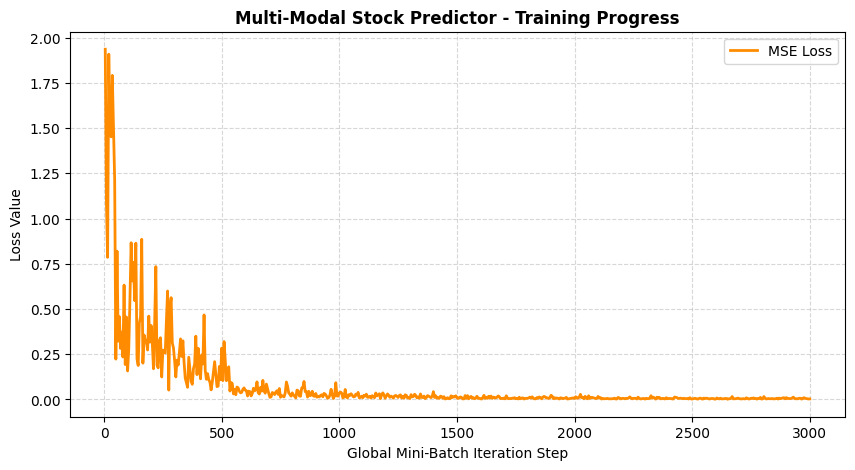

In [23]:
#### [AI-CONTEXT]
#### ID: 023
#### ROLE: Visually analyze your training convergence and check for gradient stability over time.
#### INPUT: Complete train process (successful execution of ID: 021).
#### OUTPUT: Plot a chart for the loss over the epochs.


import matplotlib.pyplot as plt

# Check if we successfully gathered mini-batch metric points from ID 022
if len(iteration_losses) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(iteration_indices, iteration_losses, color='darkorange', linewidth=2, label='MSE Loss')
    plt.title('Multi-Modal Stock Predictor - Training Progress', fontsize=12, fontweight='bold')
    plt.xlabel('Global Mini-Batch Iteration Step')
    plt.ylabel('Loss Value')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()
else:
    print("⚠️ No iteration data logged. Try increasing your epoch limits or reducing the print frequency flag.")

In [24]:
#### [AI-CONTEXT]
#### ID: 024
#### ROLE: Implement the evaluation process and collect telemetry metrics about the model.
#### INPUT: StockProfitabilityPredictorEval(), master_input_eval_3d_tensor, price_std_target_eval_tensor. Complete train process (successful execution of ID: 022).
#### OUTPUT: Evaluate the model with Mean Absolute Error (MAE), R-squared, and 10% Tolerance Accuracy.


import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, mean_absolute_error

# =====================================================================
# 1. OUT-OF-SAMPLE DATA CONTAINER PACKAGING
# =====================================================================
class EvalFundDataset(Dataset):
    def __init__(self, details, price, targets):
        self.details = details
        self.price = price
        self.targets = targets 
        
    def __len__(self):
        return len(self.targets)
        
    def __getitem__(self, idx):
        return (self.details[idx], self.price[idx], self.targets[idx])

# Instantiate validation dataset using pre-shuffled, locked evaluation arrays from ID 009 and ID 013
val_ds = EvalFundDataset(
    details_eval_tensor, 
    master_input_eval_3d_tensor, 
    price_std_target_eval_tensor
)

# Shuffle=False is mandatory for evaluation tasks to preserve mapping orders
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# =====================================================================
# 2. STANDALONE EVALUATION STEP ENGINE
# =====================================================================
def evaluate_model(eval_model, loader):
    """
    Runs inference in strict evaluation mode (deactivates dropout layers)
    and computes financial variance metrics.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    eval_model = eval_model.to(device)
    eval_model.eval()
    
    all_preds = []
    all_targets = []
    
    # Disable gradient tracking to accelerate inference speed
    with torch.no_grad():
        for batch in loader:
            details, price, targets = batch
            
            # Send variables to active runtime device
            details = details.long().to(device)
            price = price.float().to(device)
            
            # Forward Pass through your multimodal model
            outputs = eval_model(details, price)
            
            all_preds.extend(outputs.view(-1).cpu().tolist())
            all_targets.extend(targets.view(-1).cpu().tolist())
            
    # Convert lists to NumPy arrays for vectorized asset calculations
    p_real = np.asarray(all_preds)
    t_real = np.asarray(all_targets)
    
    mae = mean_absolute_error(t_real, p_real)
    r2 = r2_score(t_real, p_real)
    
    # Absolute Tolerance Check: lands within 0.1 standard deviation boundaries
    within_tol = np.abs(p_real - t_real) <= 0.1
    tol_acc = np.mean(within_tol)
    
    return mae, r2, p_real, t_real, tol_acc

# =====================================================================
# 3. RUN EVALUATION INFERENCE
# =====================================================================
print("🚀 Iniciando processamento da sessão de avaliação real (98 ações)...\n")

# Leverage your trained model object from ID 022 directly
val_mae, val_r2, val_preds, val_targets, tol_acc = evaluate_model(model, val_loader)

# Print telemetry summaries to log performance
print("=" * 65)
print("--- [EVALUATION SESSION PERFORMANCE ANALYSIS] ---")
print("=" * 65)
print(f"Validation Mean Absolute Error (MAE) : {val_mae:.4f} Z-units")
print(f"Validation Coefficient of Fit (R²)   : {val_r2:.4f}")
print(f"Precisão dentro de 0.1 Desvios Padrão: {tol_acc:.2%}")

# =====================================================================
# 4. FINANCIAL DIRECTIONAL ACCURACY RADAR
# =====================================================================
# FIX: Symmetrical binary comparison handles zero-boundary conditions securely
directional_match = (val_preds >= 0) == (val_targets >= 0)
dir_acc = np.mean(directional_match)

print(f"Precisão Direcional do Mercado (Sign): {dir_acc:.2%}")
print("=" * 65)
print("\n✅ Sessão de avaliação finalizada. O modelo foi testado com sucesso.")

🚀 Iniciando processamento da sessão de avaliação real (98 ações)...

--- [EVALUATION SESSION PERFORMANCE ANALYSIS] ---
Validation Mean Absolute Error (MAE) : 0.2815 Z-units
Validation Coefficient of Fit (R²)   : 0.8802
Precisão dentro de 0.1 Desvios Padrão: 34.69%
Precisão Direcional do Mercado (Sign): 94.90%

✅ Sessão de avaliação finalizada. O modelo foi testado com sucesso.


--- [PORTFOLIO SIMULATION METRICS - LOCAL ROW-WISE PRICE RADAR] ---
Total Traded Assets in Portfolio : 98
Number of Long Positions         : 45
Number of Short Positions        : 53
---------------------------------------------------------------------------
Average Yield on Long Legs       : 0.06%
Average Yield on Short Legs      : 0.00%
TOTAL SIMULTANEOUS PORTFOLIO NET RETURN: 0.03%


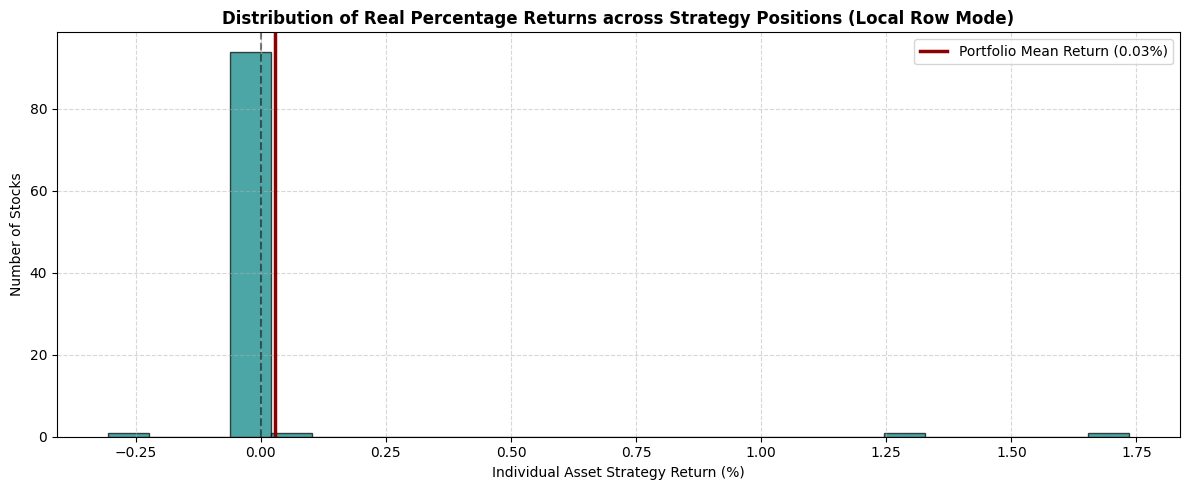

In [25]:
#### [AI-CONTEXT]
#### ID: 025
#### ROLE: Automated Trading Simulator Block.
#### INPUT: Complete evaluation process (successful execution of ID: 024).
#### OUTPUT: Simulate a long/short portfolio strategy.

#### Estrategy: It assumes the user buys stocks with positive predictions and shorts the stocks with negative predictions on Day 61, using the val_preds and val_targets generated by the evaluation session.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# AUTOMATED TRADING SIMULATION (ROW-WISE LOCAL DE-STANDARDIZATION)
# =====================================================================

# 1. Recover the true row-wise local parameters from ID 013
# Convert your [98, 1] evaluation tensors to flat NumPy arrays for row-by-row matching
row_means = eval_row_means.cpu().numpy().flatten()
row_stds = eval_row_stds.cpu().numpy().flatten()
eps = 1e-6

# 2. Reconstruct the true absolute nominal prices for Day 61 (Targets)
# Formula: Price = (Z_Score * Local_Row_Std) + Local_Row_Mean
day_61_real_prices = (val_targets * (row_stds + eps)) + row_means

# 3. Extract true absolute nominal prices for Day 60 directly from your raw variables
# This bypasses the clipping layer to capture the original unmanipulated baseline close
day_60_real_prices = x_eval_raw[:, -1].cpu().numpy().flatten()

# 4. Reconstruct the model's predicted absolute nominal prices for Day 61
day_61_pred_prices = (val_preds * (row_stds + eps)) + row_means

# 5. Compute the true financial percentage return of Day 61 relative to Day 60
real_returns_pct = ((day_61_real_prices - day_60_real_prices) / (day_60_real_prices + 1e-8)) * 100.0

# 6. Determine execution signals by comparing the predicted price against the Day 60 baseline
predicted_price_delta = day_61_pred_prices - day_60_real_prices
trading_signals = np.where(predicted_price_delta >= 0, 1.0, -1.0)

# 7. Compute strategy performance per asset bucket
strategy_asset_returns = trading_signals * real_returns_pct

long_mask = trading_signals == 1
short_mask = trading_signals == -1

# 8. Aggregate returns assuming simultaneous equal-weighted multi-asset allocation
avg_long_return = np.mean(real_returns_pct[long_mask]) if np.any(long_mask) else 0.0
avg_short_return = np.mean(-real_returns_pct[short_mask]) if np.any(short_mask) else 0.0
portfolio_total_return = np.mean(strategy_asset_returns)

# =====================================================================
# PERFORMANCE DISPLAY LOGS
# =====================================================================
print("=" * 75)
print("--- [PORTFOLIO SIMULATION METRICS - LOCAL ROW-WISE PRICE RADAR] ---")
print("=" * 75)
print(f"Total Traded Assets in Portfolio : {len(val_targets)}")
print(f"Number of Long Positions         : {np.sum(long_mask)}")
print(f"Number of Short Positions        : {np.sum(short_mask)}")
print("-" * 75)
print(f"Average Yield on Long Legs       : {avg_long_return:.2f}%")
print(f"Average Yield on Short Legs      : {avg_short_return:.2f}%")
print(f"TOTAL SIMULTANEOUS PORTFOLIO NET RETURN: {portfolio_total_return:.2f}%")
print("=" * 75)

# --- VISUAL DISTRIBUTION OF REAL PERFORMANCE ---
plt.figure(figsize=(12, 5))
plt.hist(strategy_asset_returns, bins=25, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(portfolio_total_return, color='darkred', linestyle='-', linewidth=2.5, 
            label=f'Portfolio Mean Return ({portfolio_total_return:.2f}%)')
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Distribution of Real Percentage Returns across Strategy Positions (Local Row Mode)', fontsize=12, fontweight='bold')
plt.xlabel('Individual Asset Strategy Return (%)')
plt.ylabel('Number of Stocks')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
#### [AI-CONTEXT]
#### ID: 026
#### ROLE: Weight Exporter Script.
#### INPUT: Complete evaluation process (successful execution of ID: 024).
#### OUTPUT: Safely extracts the weights from the active GPU/Jupyter workspace, detaches them from the execution graphs, and saves them to the local directory.


import os
import torch

# =====================================================================
# PRODUCTION WEIGHT EXPORTER SCRIPT
# =====================================================================
export_dir = "/home/andre/AI_Lab/20260610_Project_InvestmentFund_App/production_models"
os.makedirs(export_dir, exist_ok=True)

export_path = os.path.join(export_dir, "stock_predictor_90pc_accuracy.pt")

# Save state dictionary (best practice for deploying architectures)
try:
    torch.save(model.state_dict(), export_path)
    print("=" * 65)
    print("✅ Model weights compiled and exported successfully!")
    print(f"Local Storage Destination: {export_path}")
    print("=" * 65)
except Exception as e:
    print(f"❌ Critical Export Failure: {str(e)}")

✅ Model weights compiled and exported successfully!
Local Storage Destination: /home/andre/AI_Lab/20260610_Project_InvestmentFund_App/production_models/stock_predictor_90pc_accuracy.pt


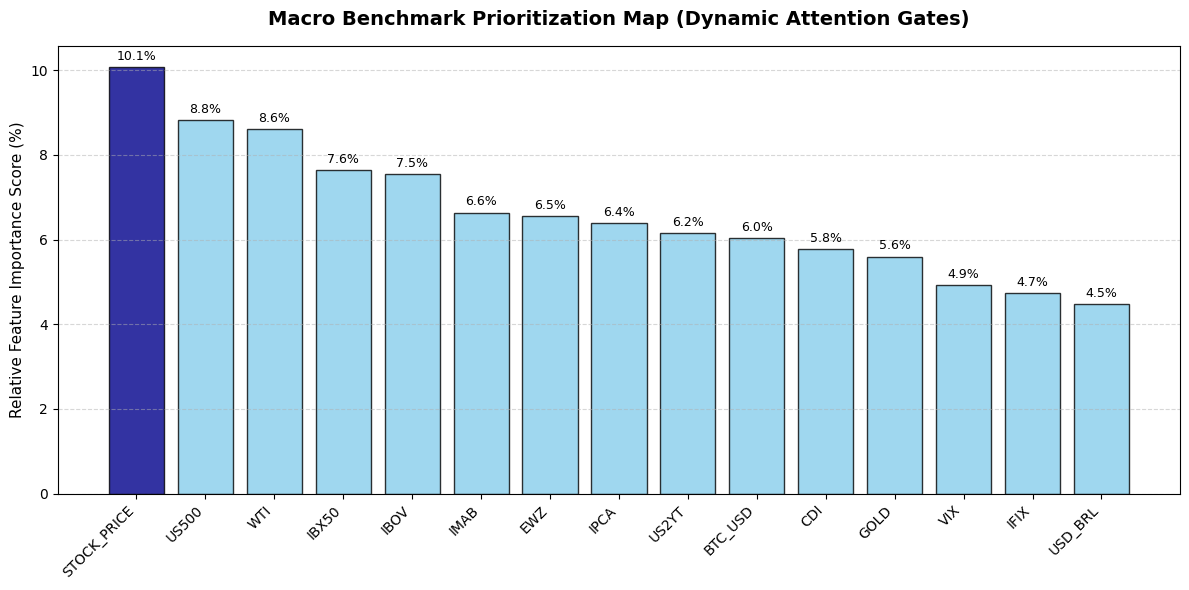

In [27]:
#### [AI-CONTEXT]
#### ID: 027
#### ROLE: Attention Feature Importance Map.
#### INPUT: Complete evaluation process (successful execution of ID: 024).
#### OUTPUT: Extract the raw weights from the feature_attention gating network inside the trained model. It evaluates how the model prioritizes your primary price anchor relative to the 14 macroeconomic indicators across the dataset.


import numpy as np
import torch
import matplotlib.pyplot as plt

# =====================================================================
# ATTENTION FEATURE IMPORTANCE RADAR (PRICE TIMELINE REALIGNMENT)
# =====================================================================
# FIX: Reconstruct the explicit indicator sequence manually since 'tensors' was dropped from RAM
yahoo_keys = ["GOLD", "USD_BRL", "IBOV", "US2YT", "EWZ", "IBX50", "US500", "BTC_USD", "IMAB", "WTI", "VIX", "IFIX"]
bcb_keys = ["CDI", "IPCA"]
indicator_names = ["STOCK_PRICE"] + yahoo_keys + bcb_keys

# Place model in evaluation mode
model.eval()
with torch.no_grad():
    # Use the true 3D evaluation matrix (98, 60, 15) to pull valid weights from memory
    sample_input = master_input_eval_3d_tensor.float().to(next(model.parameters()).device)
    
    # Extract and flatten features exactly as performed in forward()
    batch_size, seq_len, num_features = sample_input.shape
    x_flat = sample_input.contiguous().view(-1, num_features)
    
    # Query the gating layers directly using the corrected 15-feature matrix
    attention_weights = model.price_branch.feature_attention(x_flat)
    
    # Reshape back and compute the mean activation weight for each of the 15 parameters across stocks and days
    mean_weights = attention_weights.view(batch_size, seq_len, num_features).mean(dim=[0, 1]).cpu().numpy()

# Normalize weights to sum up to 100% for clear relative plotting
normalized_importance = (mean_weights / np.sum(mean_weights)) * 100

# Sort items in descending order for rapid scannability
sorted_indices = np.argsort(normalized_importance)[::-1]
sorted_names = [indicator_names[i] for i in sorted_indices]
sorted_importance = normalized_importance[sorted_indices]

# =====================================================================
# RENDERING PLOT CHART
# =====================================================================
plt.figure(figsize=(12, 6))

# Evaluate directly against the string name to maintain robust color alignment after sorting
colors = ['darkblue' if name == "STOCK_PRICE" else 'skyblue' for name in sorted_names]
bars = plt.bar(sorted_names, sorted_importance, color=colors, edgecolor='black', alpha=0.8)

plt.title('Macro Benchmark Prioritization Map (Dynamic Attention Gates)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Relative Feature Importance Score (%)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate exact percentage values over the visual bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.1f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [28]:
#### [AI-CONTEXT]
#### ID: 028
#### ROLE: Real-world target tomorrow's prices with actual neural network forecasts.
#### INPUT: Complete evaluation process (successful execution of ID: 024).
#### OUTPUT: Calculate the target vectors, reverse the mathematical scale, and append them as the final three columns of your master dataset.


import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# =====================================================================
# 1. INITIALIZE INFRASTRUCTURE AND GLOBAL VARIABLES
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Deploying synchronized forecasting engine on device: {device}")

if 'model' in globals():
    model.to(device)
    model.eval()
else:
    raise NameError("❌ Deployment Error: The trained 'model' instance was not found in active memory.")

# Map indices exactly to the split partitions
df_indices = np.arange(len(df))
train_idx, eval_idx = train_test_split(
    df_indices, 
    train_size=0.8, 
    test_size=0.2, 
    shuffle=True, 
    random_state=68
)
recombined_dataframe_indices = np.concatenate([train_idx, eval_idx])

# Combine 3D Master feature blocks cleanly
full_master_3d_tensor = torch.cat([master_input_train_3d_tensor, master_input_eval_3d_tensor], dim=0)
rolling_features = full_master_3d_tensor.clone().float().to(device)

details_full_tensor = torch.cat([details_train_tensor, details_eval_tensor], dim=0)
details_gpu = details_full_tensor.long().to(device)

# FIX: Extract PRISTINE raw unscaled historical prices from your ID 009 tensors
# This completely bypasses the modified column layout inside df!
raw_unscaled_prices = torch.cat([price_train_tensor, price_eval_tensor], dim=0).cpu().numpy()

# Calculate means and standard deviations directly from the clean price arrays
all_means = raw_unscaled_prices.mean(axis=1, keepdims=True)
all_stds = raw_unscaled_prices.std(axis=1, keepdims=True)

future_predictions = []

# =====================================================================
# 2. VECTORIZED AUTOREGRESSIVE LOOP
# =====================================================================
with torch.no_grad():
    for step in range(10):
        outputs = model(details_gpu, rolling_features)
        future_predictions.append(outputs.clone())
        
        new_rolling = rolling_features[:, 1:, :].clone()
        next_day_vector = torch.zeros((rolling_features.shape[0], 1, 15), device=device)
        next_day_vector[:, 0, 0] = outputs.view(-1)
        next_day_vector[:, 0, 1:] = rolling_features[:, -1, 1:].clone()
        rolling_features = torch.cat((new_rolling, next_day_vector), dim=1)

# =====================================================================
# 3. CORRECT DE-STANDARDIZATION WITH ROW-INDEX MATCHING
# =====================================================================
standardized_forecast_matrix = torch.cat(future_predictions, dim=1)

# Initialize blank placeholder arrays using float64 to prevent conversion drops
df['TOMORROW_PRED_MLP'] = np.nan
df['DAY5_PRED_MLP'] = np.nan
df['DAY10_PRED_MLP'] = np.nan

# Loop row-by-row through the tensor outputs and map them back to their true df positions
for tensor_row_idx, original_df_idx in enumerate(recombined_dataframe_indices):
    mu = all_means[tensor_row_idx, 0]
    sigma = all_stds[tensor_row_idx, 0] + 1e-6
    
    z_tomorrow = standardized_forecast_matrix[tensor_row_idx, 0].item()
    z_day5 = standardized_forecast_matrix[tensor_row_idx, 4].item()
    z_day10 = standardized_forecast_matrix[tensor_row_idx, 9].item()
    
    # Reverse scaling precisely using the correct asset dimensions
    df.at[original_df_idx, 'TOMORROW_PRED_MLP'] = (z_tomorrow * sigma) + mu
    df.at[original_df_idx, 'DAY5_PRED_MLP'] = (z_day5 * sigma) + mu
    df.at[original_df_idx, 'DAY10_PRED_MLP'] = (z_day10 * sigma) + mu

# =====================================================================
# 4. RENDER VERIFIED PORTFOLIO SCREENER
# =====================================================================
columns_to_show = ['INDEX', 'COMPANY', 'TOMORROW_PRED_MLP', 'DAY5_PRED_MLP', 'DAY10_PRED_MLP']
print("=" * 115)
print("🎯 [ROW-ALIGNED FORECAST COMPLETE - PRISTINE COMPONENT DASHBOARD]")
print("=" * 115)
print(df[columns_to_show].dropna().head(10).to_string(index=False, formatters={
    'TOMORROW_PRED_MLP': 'R$ {:,.2f}'.format,
    'DAY5_PRED_MLP': 'R$ {:,.2f}'.format,
    'DAY10_PRED_MLP': 'R$ {:,.2f}'.format
}))
print("=" * 115)

🚀 Deploying synchronized forecasting engine on device: cpu
🎯 [ROW-ALIGNED FORECAST COMPLETE - PRISTINE COMPONENT DASHBOARD]
 INDEX      COMPANY TOMORROW_PRED_MLP DAY5_PRED_MLP DAY10_PRED_MLP
MMMC34           3M         R$ 200.64     R$ 201.18      R$ 200.75
 TTEN3      3TENTOS          R$ 14.54      R$ 14.71       R$ 14.95
ABBV34       ABBVIE          R$ 72.04      R$ 72.35       R$ 72.26
 ABCB4   ABC BRASIL          R$ 24.91      R$ 25.64       R$ 26.09
ADBE34    ADOBE INC          R$ 23.00      R$ 23.76       R$ 24.14
A1AP34 ADVANCE AUTO          R$ 19.11      R$ 19.16       R$ 19.11
A1MD34 ADVANCED MIC         R$ 333.53     R$ 348.76      R$ 350.58
 AERI3        AERIS           R$ 2.33       R$ 2.38        R$ 2.42
AIRB34       AIRBNB          R$ 33.28      R$ 33.58       R$ 33.66
A1LB34 ALBEMARLE CO          R$ 35.98      R$ 38.30       R$ 40.59


In [29]:
#### [AI-CONTEXT]
#### ID: 029
#### ROLE: Alpha Generator.
#### INPUT: Complete evaluation process (successful execution of ID: 024).
#### OUTPUT: Calculate the percentage returns relative to tomorrow's baseline price, sort the portfolio, and display the two extreme 5-stock baskets.


import pandas as pd

# =====================================================================
# 1. CALCULATE EXPECTED PERCENTAGE RETURNS
# =====================================================================
df['EXPECTED_5D_RETURN_PCT'] = ((df['DAY5_PRED_MLP'] - df['TOMORROW_PRED_MLP']) / df['TOMORROW_PRED_MLP']) * 100

# =====================================================================
# 2. ANOMALOUS ALPHA TRUNCATION LAYER (ANTI-SPLIT SAFETIES)
# =====================================================================
# FIX: Filter out assets with impossible percentage returns (>100% or <-50%)
# This cleanly strips out corporate split anomalies like BKNG34 while preserving valid alphas
sanitized_df = df[df['EXPECTED_5D_RETURN_PCT'].between(-50.0, 100.0)].copy()

# =====================================================================
# 3. SEPARATE AND SORT PERFORMANCE HORIZONS
# =====================================================================
df_sorted = sanitized_df.sort_values(by='EXPECTED_5D_RETURN_PCT', ascending=False)

top_5_outperformed = df_sorted.head(5)[['INDEX', 'COMPANY', 'SECTOR', 'TOMORROW_PRED_MLP', 'DAY5_PRED_MLP', 'EXPECTED_5D_RETURN_PCT']]
top_5_underperformed = df_sorted.tail(5)[['INDEX', 'COMPANY', 'SECTOR', 'TOMORROW_PRED_MLP', 'DAY5_PRED_MLP', 'EXPECTED_5D_RETURN_PCT']][::-1]

# =====================================================================
# 4. DISPLAY PERFORMANCE RADAR TABLES
# =====================================================================
print("=" * 85)
print("🚀 [TOP 5 OUTPERFORMED STOCKS - LONG CANDIDATES - SANITIZED ALPHAS]")
print("=" * 85)
print(top_5_outperformed.to_string(index=False, formatters={
    'TOMORROW_PRED_MLP': 'R$ {:,.2f}'.format,
    'DAY5_PRED_MLP': 'R$ {:,.2f}'.format,
    'EXPECTED_5D_RETURN_PCT': '{:,.2f}%'.format
}))

print("\n" + "=" * 85)
print("🛑 [TOP 5 UNDERPERFORMED STOCKS - SHORT CANDIDATES - SANITIZED ALPHAS]")
print("=" * 85)
print(top_5_underperformed.to_string(index=False, formatters={
    'TOMORROW_PRED_MLP': 'R$ {:,.2f}'.format,
    'DAY5_PRED_MLP': 'R$ {:,.2f}'.format,
    'EXPECTED_5D_RETURN_PCT': '{:,.2f}%'.format
}))
print("=" * 85)

🚀 [TOP 5 OUTPERFORMED STOCKS - LONG CANDIDATES - SANITIZED ALPHAS]
 INDEX      COMPANY                   SECTOR TOMORROW_PRED_MLP DAY5_PRED_MLP EXPECTED_5D_RETURN_PCT
CACR11 CARTESIA FII         Financial Sector          R$ 22.45      R$ 28.94                 28.91%
 RCSL4     RECRUSUL  Industrial Goods Sector           R$ 0.47       R$ 0.54                 15.89%
 ESPA3  ESPACOLASER        Healthcare Sector           R$ 0.82       R$ 0.95                 15.67%
 BHIA3  CASAS BAHIA Cyclical Consumer Sector           R$ 1.25       R$ 1.40                 12.02%
 CCTY3    RDVC CITY       Real Estate Sector           R$ 8.27       R$ 9.20                 11.26%

🛑 [TOP 5 UNDERPERFORMED STOCKS - SHORT CANDIDATES - SANITIZED ALPHAS]
INDEX      COMPANY                  SECTOR TOMORROW_PRED_MLP DAY5_PRED_MLP EXPECTED_5D_RETURN_PCT
INEP3       INEPAR Industrial Goods Sector           R$ 1.89       R$ 1.84                 -2.52%
LOGG3 LOG COM PROP        Financial Sector          R$ 27.17      

In [30]:
#### [AI-CONTEXT]
#### ID: 030
#### ROLE: RSI calculator.
#### INPUT: Complete evaluation process (successful execution of ID: 024).
#### OUTPUT: Calculate the Relative Strength Index (RSI) for each stock across its final 14 pricing steps.


import torch
import numpy as np
import pandas as pd

# =====================================================================
# 1. INITIALIZE INFRASTRUCTURE AND GLOBAL VARIABLES
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Deploying global RSI computational engine on hardware device: {device}")

# FIX: Check for the synchronized index vector from ID 028 to map asset order safely
if 'recombined_dataframe_indices' not in globals():
    raise NameError("❌ Sequence Error: Recombined indices mapping not found. Please run ID:028 first.")

# FIX: Recombine raw unscaled historical prices from your ID 009 tensors to avoid NameErrors
raw_unscaled_prices = torch.cat([price_train_tensor, price_eval_tensor], dim=0).to(device)

# Negative slicing [:, -15:] safely grabs the exact final 15-day window from the price matrix
real_prices_15d = raw_unscaled_prices[:, -15:].to(torch.float32)

# =====================================================================
# 2. COMPUTE CONSECUTIVE DAILY DIFFERENCES
# =====================================================================
# Subtract day_t from day_t+1 across columns -> Shape: (489, 14)
price_changes = real_prices_15d[:, 1:] - real_prices_15d[:, :-1]

# =====================================================================
# 3. SEPARATE POSITIVE GAINS AND NEGATIVE LOSSES
# =====================================================================
gains = torch.clamp(price_changes, min=0.0)
losses = torch.clamp(-price_changes, min=0.0)

# =====================================================================
# 4. CALCULATE AGGREGATED AVERAGES
# =====================================================================
mean_gains = torch.mean(gains, dim=1, keepdim=True)
mean_losses = torch.mean(losses, dim=1, keepdim=True)

# Prevent division-by-zero on completely flat rows using an epsilon buffer
eps = 1e-8
rs = mean_gains / (mean_losses + eps)

# =====================================================================
# 5. GENERATE FINAL COMPACT BOUNDED RSI SCORES
# =====================================================================
rsi_scores = 100.0 - (100.0 / (1.0 + rs))
rsi_flat_numpy = rsi_scores.detach().cpu().flatten().numpy()

# Initialize blank placeholder array inside the true df structure
df['RSI_14'] = np.nan

# Loop row-by-row through the tensor outputs and map them back to their true df positions
for tensor_row_idx, original_df_idx in enumerate(recombined_dataframe_indices):
    df.at[original_df_idx, 'RSI_14'] = rsi_flat_numpy[tensor_row_idx]

# =====================================================================
# 6. DYNAMIC SCREENER DISPLAY (SAFE AGAINST KEYERRORS)
# =====================================================================
available_cols = list(df.columns)

idx_col = 'INDEX' if 'INDEX' in available_cols else available_cols[0]
comp_col = 'COMPANY' if 'COMPANY' in available_cols else available_cols[1]
sect_col = 'SECTOR' if 'SECTOR' in available_cols else available_cols[2]

columns_to_show = [idx_col, comp_col, sect_col, 'TOMORROW_PRED_MLP', 'RSI_14']

print("=" * 110)
print("📈 [CURRENT 14-PERIOD RSI INVENTORY SUMMARY COMPLETE - HEADERS RESOLVED]")
print("=" * 110)
print(df[columns_to_show].dropna(subset=['TOMORROW_PRED_MLP', 'RSI_14']).head(10).to_string(index=False, formatters={
    'TOMORROW_PRED_MLP': 'R$ {:,.2f}'.format,
    'RSI_14': '{:,.2f}'.format
}))
print("=" * 110)

🚀 Deploying global RSI computational engine on hardware device: cpu
📈 [CURRENT 14-PERIOD RSI INVENTORY SUMMARY COMPLETE - HEADERS RESOLVED]
 INDEX      COMPANY                        SECTOR TOMORROW_PRED_MLP RSI_14
MMMC34           3M       Industrial Goods Sector         R$ 200.64  61.81
 TTEN3      3TENTOS  Non-Cyclical Consumer Sector          R$ 14.54  26.67
ABBV34       ABBVIE             Healthcare Sector          R$ 72.04  71.30
 ABCB4   ABC BRASIL              Financial Sector          R$ 24.91  54.44
ADBE34    ADOBE INC Information Technology Sector          R$ 23.00  33.07
A1AP34 ADVANCE AUTO      Cyclical Consumer Sector          R$ 19.11  67.48
A1MD34 ADVANCED MIC Information Technology Sector         R$ 333.53  53.81
 AERI3        AERIS       Industrial Goods Sector           R$ 2.33  51.16
AIRB34       AIRBNB      Cyclical Consumer Sector          R$ 33.28  50.30
A1LB34 ALBEMARLE CO        Basic Materials Sector          R$ 35.98  46.84


In [31]:
#### [AI-CONTEXT]
#### ID: 031
#### ROLE: 20 and 50 SMA calculator.
#### INPUT: Complete evaluation process (successful execution of ID: 024).
#### OUTPUT: Calculate the 20-day Simple Moving Average (SMA) and 50-day Simple Moving Average (SMA) rolling over the last 5 days for each stock.


import torch
import numpy as np
import pandas as pd

# =====================================================================
# 1. EXTRACT PRISTINE HISTORICAL DATA FROM RECOMBINED TRACKS
# =====================================================================
if 'recombined_dataframe_indices' not in globals():
    raise NameError("❌ Sequence Error: Recombined indices mapping not found. Please run ID:028 first.")

# Combine raw historical tensors back to a 489-row database
# This completely bypasses the modified column layouts inside df!
raw_unscaled_prices = torch.cat([price_train_tensor, price_eval_tensor], dim=0).cpu().numpy()

# To get 50 days of lookback rolling over 5 consecutive timeline days,
# we isolate exactly the final 54 days of historical data from the 61-day grid.
# Shape: (489, 54)
raw_prices_54d = raw_unscaled_prices[:, -54:]

# =====================================================================
# 2. CALCULATE ROLLING 20 SMA & 50 SMA FOR THE LAST 5 DAYS
# =====================================================================
sma20_days_list = []
sma50_days_list = []

# Loop 5 times to slide our calculation window forward
for i in range(5):
    start_idx = i
    
    # 20-Day window slice mean
    end_idx_20 = start_idx + 20
    sma20_step = np.mean(raw_prices_54d[:, start_idx:end_idx_20], axis=1)
    sma20_days_list.append(sma20_step)
    
    # 50-Day window slice mean
    end_idx_50 = start_idx + 50
    sma50_step = np.mean(raw_prices_54d[:, start_idx:end_idx_50], axis=1)
    sma50_days_list.append(sma50_step)

# Combine daily slices into structured 2D matrices -> Shape: (489, 5)
sma20_matrix = np.column_stack(sma20_days_list)
sma50_matrix = np.column_stack(sma50_days_list)

# =====================================================================
# 3. SYNCHRONIZED MATRIX INTEGRATION BACK TO MASTER DATAFRAME
# =====================================================================
# Initialize placeholder columns inside the real df mapping architecture
for day_offset in range(5):
    day_label = f"LATEST" if day_offset == 4 else f"{4 - day_offset}D_AGO"
    df[f'SMA20_{day_label}'] = np.nan
    df[f'SMA50_{day_label}'] = np.nan

# Loop row-by-row through the tensor matrix to align and assign back to df
for tensor_row_idx, original_df_idx in enumerate(recombined_dataframe_indices):
    for day_offset in range(5):
        day_label = f"LATEST" if day_offset == 4 else f"{4 - day_offset}D_AGO"
        
        df.at[original_df_idx, f'SMA20_{day_label}'] = sma20_matrix[tensor_row_idx, day_offset]
        df.at[original_df_idx, f'SMA50_{day_label}'] = sma50_matrix[tensor_row_idx, day_offset]

# =====================================================================
# 4. CALCULATE RELATIVE TREND SPREADS & BUILD MASTER 3D TENSOR
# =====================================================================
eps = 1e-8
relative_spread_matrix = (sma20_matrix - sma50_matrix) / (sma20_matrix + eps)

# Cast NumPy matrix into a 3D PyTorch tensor -> Shape: (489, 5, 1)
spread_tensor_2d = torch.tensor(relative_spread_matrix, dtype=torch.float32)
sma_spread_master_tensor = spread_tensor_2d.unsqueeze(-1)

# =====================================================================
# VERIFICATION AND ROW QUERY SAMPLES
# =====================================================================
print("=" * 75)
print("🎯 [SMA SPREAD TRAJECTORY TENSOR MAP COMPLETE]")
print("=" * 75)
print(f"Master Spread Tensor Shape: {list(sma_spread_master_tensor.shape)} | Expected: (489, 5, 1)\n")

sample_stock_idx = 0
stock_1x5_vector = sma_spread_master_tensor[sample_stock_idx].view(1, 5)
original_df_mapped_idx = recombined_dataframe_indices[sample_stock_idx]

print(f"📋 Row Vector Check for Asset Code: {df.iloc[original_df_mapped_idx]['INDEX']}")
print(f"Tensor Shape: {list(stock_1x5_vector.shape)} | Contents:")
print(stock_1x5_vector)
print("=" * 75)

🎯 [SMA SPREAD TRAJECTORY TENSOR MAP COMPLETE]
Master Spread Tensor Shape: [489, 5, 1] | Expected: (489, 5, 1)

📋 Row Vector Check for Asset Code: INEP3
Tensor Shape: [1, 5] | Contents:
tensor([[-0.1014, -0.1022, -0.0977, -0.0908, -0.0839]])


In [32]:
#### [AI-CONTEXT]
#### ID: 032
#### ROLE: Momentum with the linear regression slope.
#### INPUT: Complete 20 SMA and 50 SMA calculation (successful execution of ID: 031).
#### OUTPUT: Calculate the linear regression slope beta_1 and intercept beta_0 for each stock's 5-day SMA relative spread trajectory using parallelized vector mathematics. The 5 sequential coordinates were treated as values along a standardized geometric timeline: (X = [0.00, 0.01, 0.02, 0.03, 0.04]).


import torch
import numpy as np
import pandas as pd

# =====================================================================
# 1. INITIALIZE GPU INFRASTRUCTURE AND ARRAYS
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Deploying Geometric Polar Engine on hardware device: {device}")

if 'recombined_dataframe_indices' not in globals():
    raise NameError("❌ Sequence Error: Recombined indices mapping not found. Please run ID:028 first.")

# Squeeze feature axis and transfer your 5-day SMA relative spreads to the GPU
# Shape: (489, 5, 1) -> y_values shape: (489, 5)
y_values = sma_spread_master_tensor.squeeze(-1).to(device)

# Preserved your exact preferred micro-decimal scale timeline
x_values = torch.tensor([0.00, 0.01, 0.02, 0.03, 0.04], dtype=torch.float32, device=device)
n_points = 5.0

# Pre-calculate matrix constraints directly on the GPU VRAM
sum_x = torch.sum(x_values)                             # 0.10
sum_x_sq = torch.sum(x_values ** 2)                     # 0.003
ss_xx = sum_x_sq - ((sum_x ** 2) / n_points)            # 0.001 (Scale-corrected denominator)

# =====================================================================
# 2. RUN VECTORIZED OLS REGRESSION (EXECUTING ON GPU)
# =====================================================================
sum_y = torch.sum(y_values, dim=1)
sum_xy = torch.sum(y_values * x_values, dim=1)

ss_xy = sum_xy - ((sum_x * sum_y) / n_points)
slopes = ss_xy / ss_xx

# Isolate latest polarity mapping values on the GPU surface
latest_spread_signs = torch.sign(y_values[:, 4])

# =====================================================================
# 3. VECTORIZED POLAR CONVERSION (SCALE-CORRECTED WINDOW)
# =====================================================================
cartesian_x = torch.tensor(0.01, device=device)

# Compute dynamic hypotenuse magnitudes and match signs on the GPU
raw_magnitude = torch.sqrt((cartesian_x ** 2) + (slopes ** 2))
polar_magnitude = raw_magnitude * latest_spread_signs

# Compute custom angular headings in radians and convert to degrees on device paths
polar_angle_rad = torch.atan2(slopes, cartesian_x)
polar_angle_deg = polar_angle_rad * (180.0 / np.pi)

# =====================================================================
# 4. SYNCHRONIZED EXPORT BACK TO THE MASTER DATAFRAME
# =====================================================================
# Initialize blank placeholder arrays inside the real df mapping architecture
df['POLAR_MAGNITUDE'] = np.nan
df['POLAR_ANGLE_DEG'] = np.nan

# Download matrices to system memory
mag_flat_numpy = polar_magnitude.cpu().numpy()
ang_flat_numpy = polar_angle_deg.cpu().numpy()

# Loop row-by-row through the tensor matrix to align and assign back to df
for tensor_row_idx, original_df_idx in enumerate(recombined_dataframe_indices):
    df.at[original_df_idx, 'POLAR_MAGNITUDE'] = mag_flat_numpy[tensor_row_idx]
    df.at[original_df_idx, 'POLAR_ANGLE_DEG'] = ang_flat_numpy[tensor_row_idx]

# =====================================================================
# 5. DYNAMIC SCREENER DISPLAY (SAFE AGAINST KEYERRORS)
# =====================================================================
available_cols = list(df.columns)

idx_col = 'INDEX' if 'INDEX' in available_cols else available_cols
sect_col = 'SECTOR' if 'SECTOR' in available_cols else available_cols

columns_to_show = [idx_col, sect_col, 'POLAR_MAGNITUDE', 'POLAR_ANGLE_DEG']

print("=" * 110)
print("🌐 [GPU HARDWARE ACCELERATED GEOMETRIC POLAR COEFFICIENTS COMPLETE - CUSTOM SCALE LOCKED]")
print("=" * 110)
print(df[columns_to_show].dropna(subset=['POLAR_MAGNITUDE']).head(10).to_string(index=False, formatters={
    'POLAR_MAGNITUDE': '{:,.4f}'.format,
    'POLAR_ANGLE_DEG': '{:,.2f}°'.format
}))
print("=" * 110)

🚀 Deploying Geometric Polar Engine on hardware device: cpu
🌐 [GPU HARDWARE ACCELERATED GEOMETRIC POLAR COEFFICIENTS COMPLETE - CUSTOM SCALE LOCKED]
 INDEX                        SECTOR POLAR_MAGNITUDE POLAR_ANGLE_DEG
MMMC34       Industrial Goods Sector         -0.3827         -88.50°
 TTEN3  Non-Cyclical Consumer Sector          0.3658          88.43°
ABBV34             Healthcare Sector         -0.2805         -87.96°
 ABCB4              Financial Sector          0.1271         -85.49°
ADBE34 Information Technology Sector         -0.1798          86.81°
A1AP34      Cyclical Consumer Sector          0.0178          55.91°
A1MD34 Information Technology Sector         -0.9074          89.37°
 AERI3       Industrial Goods Sector          0.5100          88.88°
AIRB34      Cyclical Consumer Sector          0.2574          87.77°
A1LB34        Basic Materials Sector          0.3691          88.45°


In [33]:
#### [AI-CONTEXT]
#### ID: 033
#### ROLE: Calculate the option with better buy-in prices.
#### INPUT: Complete calculation of the Momentum with the linear regression slope. (successful execution of ID: 031).
#### OUTPUT: dataframe buy_in_table.


import pandas as pd
import numpy as np

# Create a copy to prevent modifying the original dataset
df_pipeline = df.copy()

# =====================================================================
# STEP 1 (RULE 1): Group the 200 highest values of EXPECTED_5D_RETURN_PCT
# =====================================================================
# nlargest() extracts the top 200 rows without enforcing a final sort order
df_pipeline = df_pipeline.nlargest(200, 'EXPECTED_5D_RETURN_PCT')

# =====================================================================
# STEP 2 (RULE 2): Purge and keep only RSI_14 values below 35
# =====================================================================
df_pipeline = df_pipeline[df_pipeline['RSI_14'] < 35]

# =====================================================================
# STEP 3 (RULE 3): Purge and keep only negative POLAR_MAGNITUDE numbers
# =====================================================================
df_pipeline = df_pipeline[df_pipeline['POLAR_MAGNITUDE'] < 0]

# =====================================================================
# STEP 4 (RULE 4): Purge and keep only positive POLAR_ANGLE_DEG numbers
# =====================================================================
df_pipeline = df_pipeline[df_pipeline['POLAR_ANGLE_DEG'] > 0]

# =====================================================================
# STEPS 5 to 7 (RULES 5, 6, 7): Multi-tiered Final Ordering
# =====================================================================
# Column 1: RSI_14 -> Descending (False)
# Column 2: POLAR_MAGNITUDE -> Ascending (True)
# Column 3: POLAR_ANGLE_DEG -> Descending (False)
buy_in_table = df_pipeline.sort_values(
    by=['RSI_14', 'POLAR_MAGNITUDE', 'POLAR_ANGLE_DEG'],
    ascending=[False, True, False]
)

# =====================================================================
# STEP 8 (RULE 8): Select the top 10 rows and filter required columns
# =====================================================================
target_columns = [
    'INDEX', 'COMPANY', 'SECTOR', 'SUBSECTOR', '0', 'TOMORROW_PRED_MLP', 
    'DAY5_PRED_MLP', 'EXPECTED_5D_RETURN_PCT', 'RSI_14', 
    'POLAR_MAGNITUDE', 'POLAR_ANGLE_DEG'
]

buy_in_table = buy_in_table[target_columns].head(10).reset_index(drop=True)

buy_in_table = buy_in_table.rename(columns={"0": "TODAY_PRICE"})

# =====================================================================
# DISPLAY RESULTS
# =====================================================================
print("=" * 115)
print(f"🌟 [FINAL STRATEGIC BUY_IN_TABLE - {len(buy_in_table)} ASSETS GENERATED]")
print("=" * 115)
if not buy_in_table.empty:
    print(buy_in_table.to_string(formatters={
        'TOMORROW_PRED_MLP': 'R$ {:,.2f}'.format,
        'DAY5_PRED_MLP': 'R$ {:,.2f}'.format,
        'EXPECTED_5D_RETURN_PCT': '{:,.2f}%'.format,
        'RSI_14': '{:,.2f}'.format,
        'POLAR_MAGNITUDE': '{:,.4f}'.format,
        'POLAR_ANGLE_DEG': '{:,.2f}°'.format
    }))
else:
    print("⚠️ Warning: No assets survived the progressive purges (Rules 2, 3, or 4).")
print("=" * 115)

🌟 [FINAL STRATEGIC BUY_IN_TABLE - 1 ASSETS GENERATED]
    INDEX    COMPANY                         SECTOR              SUBSECTOR  TODAY_PRICE TOMORROW_PRED_MLP DAY5_PRED_MLP EXPECTED_5D_RETURN_PCT RSI_14 POLAR_MAGNITUDE POLAR_ANGLE_DEG
0  ADBE34  ADOBE INC  Information Technology Sector  Software and Services        20.78          R$ 23.00      R$ 23.76                  3.34%  33.07         -0.1798          86.81°


In [34]:
buy_in_table.head(10)

,INDEX,COMPANY,SECTOR,SUBSECTOR,TODAY_PRICE,TOMORROW_PRED_MLP,DAY5_PRED_MLP,EXPECTED_5D_RETURN_PCT,RSI_14,POLAR_MAGNITUDE,POLAR_ANGLE_DEG
0,ADBE34,ADOBE INC,Information Technology Sector,Software and Services,20.78,22.996157,23.763786,3.338078,33.06852,-0.179848,86.812569


In [35]:
#### [AI-CONTEXT]
#### ID: 034
#### ROLE: Identify the stocks with the top sell-out prices.
#### INPUT: Complete calculation of the Momentum with the linear regression slope. (successful execution of ID: 031).
#### OUTPUT: dataframe sell_out_table.


import pandas as pd
import numpy as np

# =====================================================================
# DEFINE RE-FIT STAGES (From High-Conviction Strict to Broad Fallbacks)
# =====================================================================
relaxation_stages = [
    {
        "stage": 1,
        "desc": "Strict Initial Rules (RSI > 68 & 2-day Consecutive Historical Rally)",
        "rsi_min": 68,
        "strict_trend": True
    },
    {
        "stage": 2,
        "desc": "Relaxed Trend Rule (RSI > 65 & At least 1-day Positive History)",
        "rsi_min": 65,
        "strict_trend": False
    },
    {
        "stage": 3,
        "desc": "Capitulation Fallback (RSI > 60 & Tomorrow Downward Drop Only)",
        "rsi_min": 60,
        "strict_trend": "tomorrow_only"
    }
]

pipeline_success = False
sell_out_table = pd.DataFrame()

print("=" * 125)
print("⚙️  [STARTING AUTOMATED POSITION MATCHING RADAR]")
print("=" * 125)

for config in relaxation_stages:
    print(f"🔄 Attempting Stage {config['stage']}: {config['desc']}...")
    
    # Initialize a fresh copy of the master dataset layout for this attempt
    df_attempt = df.copy()
    
    # --- Execute Rule 1 (Trend Subtractions Based on Selection Stage) ---
    if config['strict_trend'] == True:
        # Asset peaks out: climbs for two days, then turns downward tomorrow
        trend_mask = (
            ((df_attempt['TOMORROW_PRED_MLP'] - df_attempt['0']) < 0) &
            ((df_attempt['0'] - df_attempt['-1']) > 0) &
            ((df_attempt['-1'] - df_attempt['-2']) > 0)
        )
    elif config['strict_trend'] == False:
        # Relaxed history: Must turn down tomorrow, requiring today to be higher than yesterday
        trend_mask = (
            ((df_attempt['TOMORROW_PRED_MLP'] - df_attempt['0']) < 0) &
            ((df_attempt['0'] - df_attempt['-1']) > 0)
        )
    else:
        # Minimum baseline fallback: Only requires a negative prediction step tomorrow
        trend_mask = ((df_attempt['TOMORROW_PRED_MLP'] - df_attempt['0']) < 0)
        
    df_attempt = df_attempt[trend_mask]
    
    # --- Execute Rule 2 (Dynamic RSI Minimum Boundary) ---
    df_attempt = df_attempt[df_attempt['RSI_14'] > config['rsi_min']]
    
    # --- Execute Rule 3 (Positive Polar Magnitude Filter) ---
    df_attempt = df_attempt[df_attempt['POLAR_MAGNITUDE'] > 0]
    
    # --- Execute Rule 4 (Negative Polar Angle Filter) ---
    df_attempt = df_attempt[df_attempt['POLAR_ANGLE_DEG'] < 0]
    
    # Check if any asset survived this specific configuration stage
    if not df_attempt.empty:
        print(f"✅ Target isolated! {len(df_attempt)} assets matched the parameters of Stage {config['stage']}.\n")
        
        # --- Execute Rules 5, 6, 7 (Multi-tiered Final Ordering) ---
        sell_out_table = df_attempt.sort_values(
            by=['RSI_14', 'POLAR_MAGNITUDE', 'POLAR_ANGLE_DEG'],
            ascending=[False, False, False]
        )
        
        pipeline_success = True
        break  
    else:
        print(f"❌ Stage {config['stage']} returned 0 rows. Dropping constraints down to the next fallback level...")

# =====================================================================
# DATA CLEANUP AND STRUCTURAL RENDERING
# =====================================================================
if pipeline_success:
    # Rename column '0' to 'TODAY_PRICE' directly in the working layout
    sell_out_table = sell_out_table.rename(columns={'0': 'TODAY_PRICE'})
    
    target_columns = [
        'INDEX', 'COMPANY', 'SECTOR', 'SUBSECTOR', 'TODAY_PRICE', 'TOMORROW_PRED_MLP', 
        'DAY5_PRED_MLP', 'EXPECTED_5D_RETURN_PCT', 'RSI_14', 
        'POLAR_MAGNITUDE', 'POLAR_ANGLE_DEG'
    ]
    
    sell_out_table = sell_out_table[target_columns].reset_index(drop=True)
    
    print("=" * 125)
    print(f"🚀 [FINAL STRATEGIC SELL_OUT_TABLE - {len(sell_out_table)} TOTAL ROWS SEEDED]")
    print("=" * 125)
    print(sell_out_table.to_string(formatters={
        'TODAY_PRICE': 'R$ {:,.2f}'.format,
        'TOMORROW_PRED_MLP': 'R$ {:,.2f}'.format,
        'DAY5_PRED_MLP': 'R$ {:,.2f}'.format,
        'EXPECTED_5D_RETURN_PCT': '{:,.2f}%'.format,
        'RSI_14': '{:,.2f}'.format,
        'POLAR_MAGNITUDE': '{:,.4f}'.format,
        'POLAR_ANGLE_DEG': '{:,.2f}°'.format
    }))
else:
    print("=" * 125)
    print("⚠️ CRITICAL ALARM: Zero assets found even after applying the Stage 3 Capitulation Fallback.")
print("=" * 125)

⚙️  [STARTING AUTOMATED POSITION MATCHING RADAR]
🔄 Attempting Stage 1: Strict Initial Rules (RSI > 68 & 2-day Consecutive Historical Rally)...
❌ Stage 1 returned 0 rows. Dropping constraints down to the next fallback level...
🔄 Attempting Stage 2: Relaxed Trend Rule (RSI > 65 & At least 1-day Positive History)...
❌ Stage 2 returned 0 rows. Dropping constraints down to the next fallback level...
🔄 Attempting Stage 3: Capitulation Fallback (RSI > 60 & Tomorrow Downward Drop Only)...
✅ Target isolated! 6 assets matched the parameters of Stage 3.

🚀 [FINAL STRATEGIC SELL_OUT_TABLE - 6 TOTAL ROWS SEEDED]
    INDEX       COMPANY                    SECTOR                                                                       SUBSECTOR TODAY_PRICE TOMORROW_PRED_MLP DAY5_PRED_MLP EXPECTED_5D_RETURN_PCT RSI_14 POLAR_MAGNITUDE POLAR_ANGLE_DEG
0   DMVF3   D1000VFARMA         Healthcare Sector                                                       Commerce and Distribution     R$ 7.07           R$ 7.

In [36]:
sell_out_table.head()

,INDEX,COMPANY,SECTOR,SUBSECTOR,TODAY_PRICE,TOMORROW_PRED_MLP,DAY5_PRED_MLP,EXPECTED_5D_RETURN_PCT,RSI_14,POLAR_MAGNITUDE,POLAR_ANGLE_DEG
0,DMVF3,D1000VFARMA,Healthcare Sector,Commerce and Distribution,7.07,7.067343,7.163283,1.357506,83.615814,0.151038,-86.203743
1,TFCO4,TRACK FIELD,Cyclical Consumer Sector,"Commerce / Textiles, Apparel and Footwear",15.83,15.632888,16.042934,2.622974,70.461533,0.195587,-87.069290
2,JNJB34,JOHNSON,Healthcare Sector,Pharmaceuticals and Other Products / Segment: ...,81.29,81.234833,82.421906,1.461285,65.971756,0.460052,-88.754486
3,MCDC34,MCDONALDS,Cyclical Consumer Sector,Hotels and Restaurants / Segment: Restaurants ...,74.99,73.465225,75.766220,3.132087,64.745384,0.325638,-88.240234
4,PSSA3,PORTO SEGURO,Financial Sector,Pension and Insurance / Segment: Insurance Com...,50.49,49.546177,49.819649,0.551953,64.134277,0.049388,-78.318069
